CELL 1 - LOAD DAN CLEANING DATA 1 STASIUN BMKG
DATA_PATH : D:\skrisi\Data Curah hujan di semarang 2025\Baru_StasiunKlimatologi.csv
File ada  : True
RESULT_DIR: result_xgboost_1stasiun_klimatologi
Separator terdeteksi: ';'

Shape awal: (2346, 12)

Kolom awal:
['Date', 'TemperatureMin', 'TemperatureMax', 'TemperatureAverage', 'Humidity', 'RainRate', 'WindSpeedMax', 'WindspeedAverage', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']

Contoh data awal:


,Date,TemperatureMin,TemperatureMax,TemperatureAverage,Humidity,RainRate,WindSpeedMax,WindspeedAverage,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,01-01-2020,24.2,31.4,27.0,88.0,9.6,6.0,4,NaN,NaN,NaN,NaN
1,02-01-2020,24.0,31.0,27.4,87.0,16.7,6.0,3,NaN,NaN,NaN,NaN
2,03-01-2020,24.8,32.2,28.4,84.0,2.0,7.0,3,NaN,NaN,NaN,NaN
3,04-01-2020,22.0,31.4,27.1,90.0,36.6,8.0,2,NaN,NaN,NaN,NaN
4,05-01-2020,25.4,30.4,26.8,92.0,3.7,6.0,2,NaN,NaN,NaN,NaN



Kolom setelah hapus Unnamed/kosong:
['Date', 'TemperatureMin', 'TemperatureMax', 'TemperatureAverage', 'Humidity', 'RainRate', 'WindSpeedMax', 'WindspeedAverage']

Kolom setelah rename:
['Date', 'TemperatureMin', 'TemperatureMax', 'Temperature', 'Humidity', 'Rainfall', 'WindSpeedMax', 'WindSpeed']

Jumlah tanggal duplikat: 3
Shape setelah handle duplikat: (2343, 8)
Shape setelah reindex harian: (2343, 8)
Periode data: 2020-01-01 00:00:00 sampai 2026-05-31 00:00:00

Jumlah nilai tidak realistis sebelum cleaning:


,Jumlah
TemperatureMin_invalid,7
TemperatureMax_invalid,6
Temperature_invalid,8
Humidity_invalid,14
Rainfall_invalid,0
WindSpeedMax_invalid,0
WindSpeed_invalid,0



Missing value setelah cleaning:


Date                 0
TemperatureMin       0
TemperatureMax       0
Temperature          0
Humidity             0
Rainfall             0
WindSpeedMax         0
WindSpeed            0
RainToday_1mm        0
RainToday_5mm        0
TempRange            0
Humidity_Temp        0
Humidity_per_Temp    0
dtype: int64


Statistik data setelah cleaning:


,count,mean,min,25%,50%,75%,max,std
Date,2343,2023-03-17 00:00:00,2020-01-01 00:00:00,2021-08-08 12:00:00,2023-03-17 00:00:00,2024-10-22 12:00:00,2026-05-31 00:00:00,NaN
TemperatureMin,2343.0,24.92851,19.0,24.2,25.0,25.6,28.0,1.142528
TemperatureMax,2343.0,32.723261,25.0,31.6,32.6,34.0,38.8,1.768225
Temperature,2343.0,28.507533,23.8,27.7,28.4,29.2,32.4,1.257027
Humidity,2343.0,79.043406,52.0,74.0,80.0,84.0,98.0,7.486376
Rainfall,2343.0,7.428254,0.0,0.0,0.0,6.4,203.2,16.853701
WindSpeedMax,2343.0,5.292659,2.0,4.0,5.0,6.0,15.0,1.507082
WindSpeed,2343.0,2.04012,0.0,2.0,2.0,2.0,6.0,0.722999
RainToday_1mm,2343.0,0.402049,0.0,0.0,0.0,1.0,1.0,0.490416
RainToday_5mm,2343.0,0.277422,0.0,0.0,0.0,1.0,1.0,0.447822



Distribusi Rainfall:
Jumlah Rainfall = 0: 1249
Jumlah Rainfall > 0: 1094
Jumlah Rainfall >= 5 mm: 650


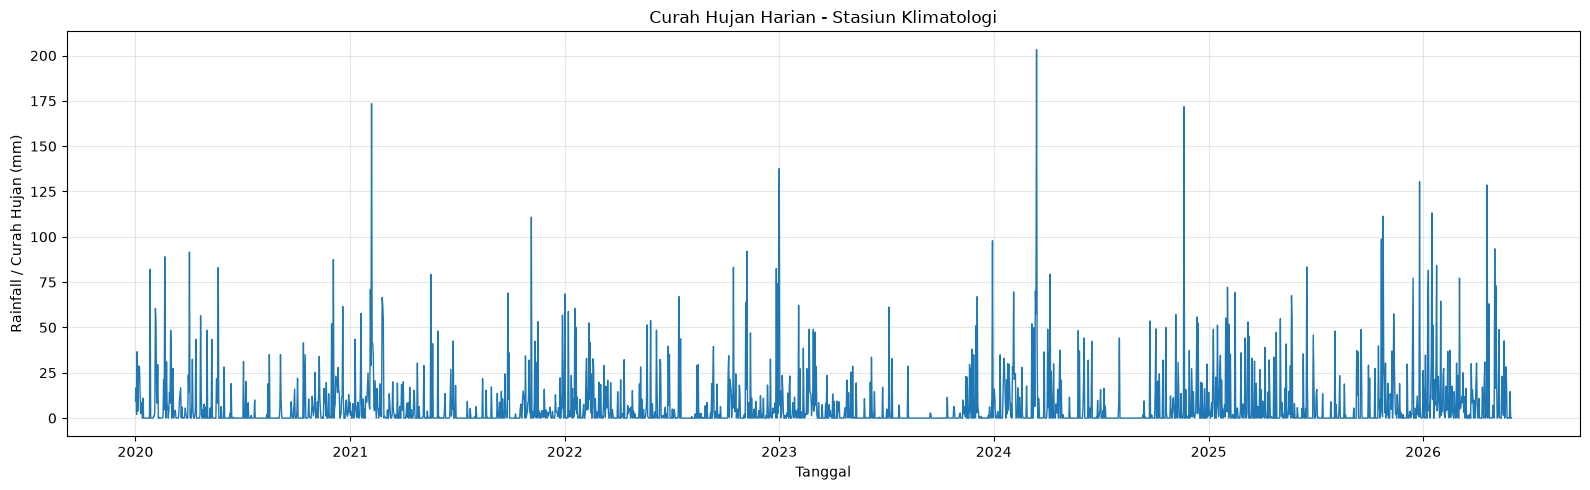


CELL 1 selesai.
File hasil cleaning disimpan di:
result_xgboost_1stasiun_klimatologi\dataset_1stasiun_clean_cell1.csv


In [10]:
# ============================== CELL 1 ==============================
# Load dan cleaning data 1 stasiun BMKG
# Fokus: Stasiun Klimatologi Semarang
# Target nanti: prediksi hujan 3 hari ke depan menggunakan XGBoost

print("=" * 80)
print("CELL 1 - LOAD DAN CLEANING DATA 1 STASIUN BMKG")
print("=" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# ==========================================================
# 1. Path data
# ==========================================================
# Sesuaikan dengan lokasi file kamu di laptop.
# Kalau file kamu ada di folder lama, pakai path ini:

DATA_PATH = Path(r"D:\skrisi\Data Curah hujan di semarang 2025\Baru_StasiunKlimatologi.csv")

# Folder hasil
RESULT_DIR = Path("result_xgboost_1stasiun_klimatologi")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_PATH :", DATA_PATH)
print("File ada  :", DATA_PATH.exists())
print("RESULT_DIR:", RESULT_DIR)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"File tidak ditemukan: {DATA_PATH}\n"
        "Cek kembali lokasi dan nama file CSV kamu."
    )

# ==========================================================
# 2. Fungsi bantu
# ==========================================================

def read_csv_auto(path):
    """
    Membaca CSV dengan beberapa kemungkinan separator.
    Data BMKG kamu memakai separator titik koma (;).
    """
    best_df = None
    best_cols = -1
    best_sep = None

    for sep in [";", ",", "\t"]:
        try:
            temp = pd.read_csv(path, sep=sep, encoding="utf-8-sig")
            if temp.shape[1] > best_cols:
                best_df = temp
                best_cols = temp.shape[1]
                best_sep = sep
        except Exception:
            pass

    if best_df is None:
        raise ValueError("File CSV gagal dibaca.")

    print("Separator terdeteksi:", repr(best_sep))
    return best_df


def clean_numeric(series):
    """
    Membersihkan angka:
    - mengubah koma menjadi titik
    - mengubah simbol kosong menjadi NaN
    - mengubah teks menjadi numeric
    """
    s = series.astype(str).str.strip()

    s = s.replace({
        "-": np.nan,
        "": np.nan,
        "nan": np.nan,
        "NaN": np.nan,
        "NULL": np.nan,
        "null": np.nan,
        "8888": np.nan,
        "9999": np.nan,
        "999.9": np.nan
    })

    s = s.str.replace(",", ".", regex=False)
    return pd.to_numeric(s, errors="coerce")


# ==========================================================
# 3. Load data awal
# ==========================================================

df_raw = read_csv_auto(DATA_PATH)

print("\nShape awal:", df_raw.shape)
print("\nKolom awal:")
print(df_raw.columns.tolist())

print("\nContoh data awal:")
display(df_raw.head())

# ==========================================================
# 4. Hapus kolom kosong / Unnamed
# ==========================================================

df = df_raw.copy()

# Hapus kolom Unnamed
df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]

# Hapus kolom yang seluruh isinya kosong
df = df.dropna(axis=1, how="all")

print("\nKolom setelah hapus Unnamed/kosong:")
print(df.columns.tolist())

# ==========================================================
# 5. Rename kolom agar konsisten
# ==========================================================

rename_map = {
    "Date": "Date",
    "Tanggal": "Date",
    "TANGGAL": "Date",

    "TemperatureMin": "TemperatureMin",
    "TemperatureMax": "TemperatureMax",
    "TemperatureAverage": "Temperature",
    "Humidity": "Humidity",
    "RainRate": "Rainfall",
    "WindSpeedMax": "WindSpeedMax",
    "WindspeedAverage": "WindSpeed",
    "WindSpeedAverage": "WindSpeed"
}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

required_columns = [
    "Date",
    "TemperatureMin",
    "TemperatureMax",
    "Temperature",
    "Humidity",
    "Rainfall",
    "WindSpeedMax",
    "WindSpeed"
]

missing_required = [c for c in required_columns if c not in df.columns]

if len(missing_required) > 0:
    raise KeyError(f"Kolom wajib tidak ditemukan: {missing_required}")

df = df[required_columns].copy()

print("\nKolom setelah rename:")
print(df.columns.tolist())

# ==========================================================
# 6. Parsing tanggal dan numeric
# ==========================================================

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce",
    dayfirst=True
)

for col in df.columns:
    if col != "Date":
        df[col] = clean_numeric(df[col])

# Hapus baris tanggal kosong
df = df.dropna(subset=["Date"]).copy()

# Urutkan tanggal
df = df.sort_values("Date").reset_index(drop=True)

# ==========================================================
# 7. Cek dan tangani tanggal duplikat
# ==========================================================

duplicate_count = df["Date"].duplicated().sum()
print("\nJumlah tanggal duplikat:", duplicate_count)

# Jika ada duplikat, ambil rata-rata numeric per tanggal
df = (
    df
    .groupby("Date", as_index=False)
    .mean(numeric_only=True)
    .sort_values("Date")
    .reset_index(drop=True)
)

print("Shape setelah handle duplikat:", df.shape)

# ==========================================================
# 8. Reindex tanggal harian agar tidak ada tanggal lompat
# ==========================================================

full_dates = pd.date_range(
    start=df["Date"].min(),
    end=df["Date"].max(),
    freq="D"
)

df = (
    df
    .set_index("Date")
    .reindex(full_dates)
    .rename_axis("Date")
    .reset_index()
)

print("Shape setelah reindex harian:", df.shape)
print("Periode data:", df["Date"].min(), "sampai", df["Date"].max())

# ==========================================================
# 9. Cleaning nilai tidak realistis
# ==========================================================
# Catatan:
# - Rainfall = 0 valid, artinya tidak hujan.
# - Temperature = 0 tidak valid untuk Semarang.
# - Humidity = 0 tidak valid.
# - WindSpeed = 0 masih bisa valid, artinya angin sangat tenang.

before_invalid = {}

before_invalid["TemperatureMin_invalid"] = ((df["TemperatureMin"] <= 0) | (df["TemperatureMin"] > 45)).sum()
before_invalid["TemperatureMax_invalid"] = ((df["TemperatureMax"] <= 0) | (df["TemperatureMax"] > 45)).sum()
before_invalid["Temperature_invalid"] = ((df["Temperature"] <= 0) | (df["Temperature"] > 45)).sum()
before_invalid["Humidity_invalid"] = ((df["Humidity"] <= 0) | (df["Humidity"] > 100)).sum()
before_invalid["Rainfall_invalid"] = ((df["Rainfall"] < 0) | (df["Rainfall"] > 500)).sum()
before_invalid["WindSpeedMax_invalid"] = ((df["WindSpeedMax"] < 0) | (df["WindSpeedMax"] > 100)).sum()
before_invalid["WindSpeed_invalid"] = ((df["WindSpeed"] < 0) | (df["WindSpeed"] > 100)).sum()

print("\nJumlah nilai tidak realistis sebelum cleaning:")
display(pd.DataFrame([before_invalid]).T.rename(columns={0: "Jumlah"}))

# Ubah nilai tidak realistis menjadi NaN
df.loc[(df["TemperatureMin"] <= 0) | (df["TemperatureMin"] > 45), "TemperatureMin"] = np.nan
df.loc[(df["TemperatureMax"] <= 0) | (df["TemperatureMax"] > 45), "TemperatureMax"] = np.nan
df.loc[(df["Temperature"] <= 0) | (df["Temperature"] > 45), "Temperature"] = np.nan
df.loc[(df["Humidity"] <= 0) | (df["Humidity"] > 100), "Humidity"] = np.nan
df.loc[(df["Rainfall"] < 0) | (df["Rainfall"] > 500), "Rainfall"] = np.nan
df.loc[(df["WindSpeedMax"] < 0) | (df["WindSpeedMax"] > 100), "WindSpeedMax"] = np.nan
df.loc[(df["WindSpeed"] < 0) | (df["WindSpeed"] > 100), "WindSpeed"] = np.nan

# ==========================================================
# 10. Isi missing value
# ==========================================================
# Untuk variabel cuaca selain rainfall: interpolasi
weather_non_rain_cols = [
    "TemperatureMin",
    "TemperatureMax",
    "Temperature",
    "Humidity",
    "WindSpeedMax",
    "WindSpeed"
]

df[weather_non_rain_cols] = (
    df[weather_non_rain_cols]
    .interpolate(method="linear", limit_direction="both")
)

# Untuk rainfall:
# Jika missing karena tanggal tidak ada, isi 0 sebagai pendekatan sederhana.
# Rainfall 0 tetap valid sebagai tidak hujan.
df["Rainfall"] = df["Rainfall"].fillna(0)

# ==========================================================
# 11. Feature dasar tambahan
# ==========================================================

df["RainToday_1mm"] = (df["Rainfall"] >= 1).astype(int)
df["RainToday_5mm"] = (df["Rainfall"] >= 5).astype(int)

df["TempRange"] = df["TemperatureMax"] - df["TemperatureMin"]
df["Humidity_Temp"] = df["Humidity"] * df["Temperature"]
df["Humidity_per_Temp"] = df["Humidity"] / (df["Temperature"] + 1e-6)

# ==========================================================
# 12. Cek hasil cleaning
# ==========================================================

print("\nMissing value setelah cleaning:")
display(df.isna().sum())

print("\nStatistik data setelah cleaning:")
display(df.describe().T.round(4))

print("\nDistribusi Rainfall:")
print("Jumlah Rainfall = 0:", int((df["Rainfall"] == 0).sum()))
print("Jumlah Rainfall > 0:", int((df["Rainfall"] > 0).sum()))
print("Jumlah Rainfall >= 5 mm:", int((df["Rainfall"] >= 5).sum()))

# ==========================================================
# 13. Grafik cepat rainfall
# ==========================================================

plt.figure(figsize=(16, 5))
plt.plot(df["Date"], df["Rainfall"], linewidth=1)
plt.title("Curah Hujan Harian - Stasiun Klimatologi")
plt.xlabel("Tanggal")
plt.ylabel("Rainfall / Curah Hujan (mm)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================================
# 14. Simpan hasil CELL 1
# ==========================================================

cell1_path = RESULT_DIR / "dataset_1stasiun_clean_cell1.csv"
df.to_csv(cell1_path, index=False)

print("\nCELL 1 selesai.")
print("File hasil cleaning disimpan di:")
print(cell1_path)

CELL 2 - FEATURE ENGINEERING DAN TARGET HUJAN 3 HARI KE DEPAN
Menggunakan dataframe df dari CELL 1.
Shape data clean: (2343, 13)
Periode: 2020-01-01 00:00:00 sampai 2026-05-31 00:00:00

RAIN_THRESHOLD_MM: 5.0

Lag features selesai.
Rolling features selesai.

Target H+1, H+2, H+3 selesai.

Shape df_feat: (2343, 622)

Top 20 missing value setelah feature engineering:


Rainfall_mean90          89
Rainfall_max90           89
Rainfall_min90           89
Rainfall_std90           89
WindSpeed_mean90         89
WindSpeed_max90          89
WindSpeed_min90          89
WindSpeed_std90          89
Humidity_mean90          89
Humidity_max90           89
Humidity_min90           89
Humidity_std90           89
Temperature_mean90       89
Temperature_max90        89
Temperature_min90        89
Temperature_std90        89
TemperatureMax_mean90    89
TemperatureMax_max90     89
TemperatureMax_min90     89
TemperatureMax_std90     89
dtype: int64


Distribusi Target_H1_Rain:


Target_H1_Rain
0.0    1693
1.0     649
NaN       1
Name: count, dtype: int64


Distribusi Target_H2_Rain:


...

Class_AnyRain_H1H3
0.0    1014
1.0    1326
NaN       3
Name: count, dtype: int64


Distribusi target intensitas 3 kelas:


Intensity3_Target_Max_H1H3
0.0    1014
1.0     623
2.0     703
NaN       3
Name: count, dtype: int64


Statistik target curah hujan:


,count,mean,std,min,25%,50%,75%,max
Target_H1_mm,2342.0,7.4273,16.8572,0.0,0.0,0.0,6.400,203.2
Target_H2_mm,2341.0,7.4234,16.8598,0.0,0.0,0.0,6.400,203.2
Target_H3_mm,2340.0,7.4257,16.8630,0.0,0.0,0.0,6.400,203.2
Target_Max_H1H3_mm,2340.0,17.3194,24.5281,0.0,0.0,7.8,26.200,203.2
Target_Total_H1H3_mm,2340.0,22.2859,32.6624,0.0,0.0,9.4,31.725,330.8


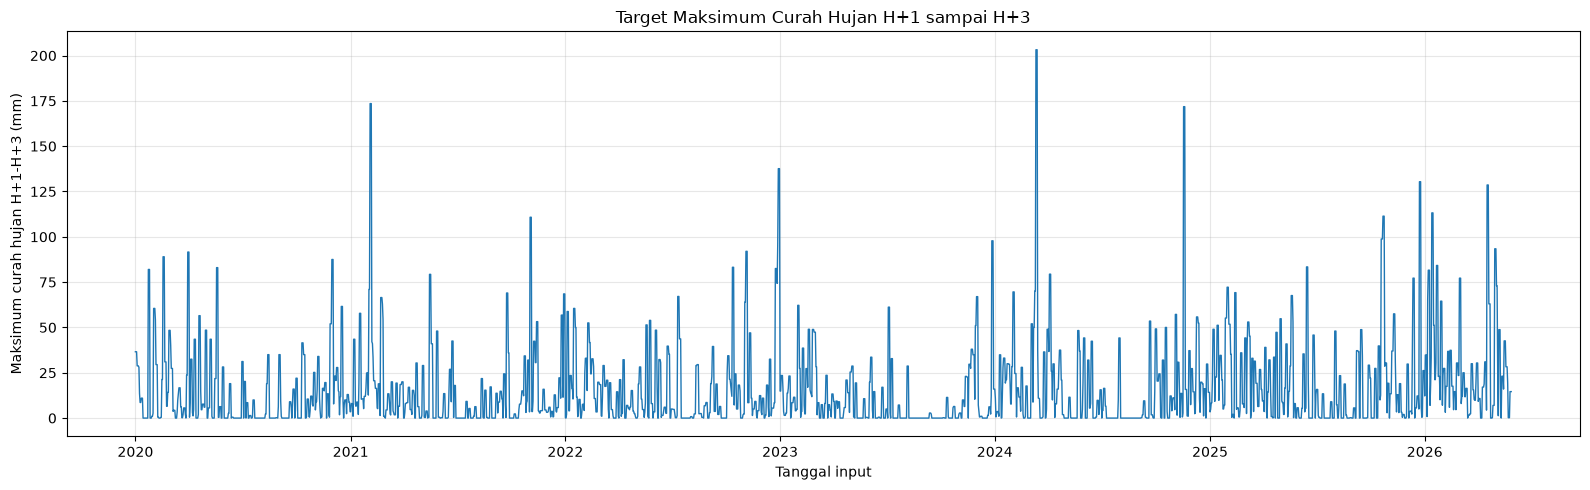


CELL 2 selesai.
File hasil feature engineering disimpan di:
result_xgboost_1stasiun_klimatologi\dataset_1stasiun_feature_target_cell2.csv


In [11]:
# ============================== CELL 2 ==============================
# Feature engineering dan target prediksi hujan 3 hari ke depan
# Pola mirip Kaggle:
# cleaning data -> calendar feature -> lag feature -> rolling feature -> target

print("=" * 80)
print("CELL 2 - FEATURE ENGINEERING DAN TARGET HUJAN 3 HARI KE DEPAN")
print("=" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================================
# 1. Cek data dari CELL 1
# ==========================================================

required_vars = ["RESULT_DIR"]

for v in required_vars:
    if v not in globals():
        raise NameError(f"{v} belum tersedia. Jalankan CELL 1 terlebih dahulu.")

if "df" in globals():
    df_clean = df.copy()
    print("Menggunakan dataframe df dari CELL 1.")
else:
    cell1_path = RESULT_DIR / "dataset_1stasiun_clean_cell1.csv"

    if not cell1_path.exists():
        raise FileNotFoundError(
            f"File hasil CELL 1 tidak ditemukan: {cell1_path}"
        )

    df_clean = pd.read_csv(cell1_path)
    print("Membaca data hasil CELL 1 dari:", cell1_path)

df_clean["Date"] = pd.to_datetime(df_clean["Date"])
df_clean = df_clean.sort_values("Date").reset_index(drop=True)

print("Shape data clean:", df_clean.shape)
print("Periode:", df_clean["Date"].min(), "sampai", df_clean["Date"].max())

# ==========================================================
# 2. Parameter target hujan
# ==========================================================
# RAIN_THRESHOLD_MM = 5 artinya hujan signifikan.
# Kalau ingin semua hujan kecil ikut dihitung, bisa ubah ke 1.0.

RAIN_THRESHOLD_MM = 5.0

print("\nRAIN_THRESHOLD_MM:", RAIN_THRESHOLD_MM)

# ==========================================================
# 3. Salin data untuk feature engineering
# ==========================================================

df_feat = df_clean.copy()

# ==========================================================
# 4. Calendar features
# ==========================================================

df_feat["Year"] = df_feat["Date"].dt.year
df_feat["Month"] = df_feat["Date"].dt.month
df_feat["Day"] = df_feat["Date"].dt.day
df_feat["DayOfYear"] = df_feat["Date"].dt.dayofyear
df_feat["WeekOfYear"] = df_feat["Date"].dt.isocalendar().week.astype(int)
df_feat["Quarter"] = df_feat["Date"].dt.quarter

# Cyclical encoding seperti pola umum di Kaggle
df_feat["Month_sin"] = np.sin(2 * np.pi * df_feat["Month"] / 12)
df_feat["Month_cos"] = np.cos(2 * np.pi * df_feat["Month"] / 12)

df_feat["DayOfYear_sin"] = np.sin(2 * np.pi * df_feat["DayOfYear"] / 365.25)
df_feat["DayOfYear_cos"] = np.cos(2 * np.pi * df_feat["DayOfYear"] / 365.25)

# Musim sederhana untuk Indonesia
df_feat["WetSeason"] = df_feat["Month"].isin([11, 12, 1, 2, 3]).astype(int)
df_feat["DrySeason"] = df_feat["Month"].isin([6, 7, 8, 9]).astype(int)
df_feat["TransitionSeason"] = (~df_feat["Month"].isin([11, 12, 1, 2, 3, 6, 7, 8, 9])).astype(int)

# ==========================================================
# 5. Feature tambahan cuaca
# ==========================================================

df_feat["TempRange"] = df_feat["TemperatureMax"] - df_feat["TemperatureMin"]
df_feat["Humidity_Temp"] = df_feat["Humidity"] * df_feat["Temperature"]
df_feat["Humidity_per_Temp"] = df_feat["Humidity"] / (df_feat["Temperature"] + 1e-6)

df_feat["RainToday_1mm"] = (df_feat["Rainfall"] >= 1.0).astype(int)
df_feat["RainToday_5mm"] = (df_feat["Rainfall"] >= RAIN_THRESHOLD_MM).astype(int)

# ==========================================================
# 6. Consecutive rain/dry days
# ==========================================================

rain_today = df_feat["RainToday_5mm"].values

consecutive_rain = []
count_rain = 0

for val in rain_today:
    if val == 1:
        count_rain += 1
    else:
        count_rain = 0

    consecutive_rain.append(count_rain)

df_feat["Consecutive_Rain_Days"] = consecutive_rain

consecutive_dry = []
count_dry = 0

for val in rain_today:
    if val == 0:
        count_dry += 1
    else:
        count_dry = 0

    consecutive_dry.append(count_dry)

df_feat["Consecutive_Dry_Days"] = consecutive_dry

# ==========================================================
# 7. Lag features
# ==========================================================
# Lag memakai data hari-hari sebelumnya.
# Ini penting untuk model XGBoost karena data curah hujan bersifat time series.

lag_cols = [
    "TemperatureMin",
    "TemperatureMax",
    "Temperature",
    "Humidity",
    "Rainfall",
    "WindSpeedMax",
    "WindSpeed",
    "TempRange",
    "Humidity_Temp",
    "Humidity_per_Temp",
    "RainToday_1mm",
    "RainToday_5mm",
    "Consecutive_Rain_Days",
    "Consecutive_Dry_Days"
]

lag_days = [1, 2, 3, 5, 7, 10, 14, 21, 30, 45, 60]

for col in lag_cols:
    for lag in lag_days:
        df_feat[f"{col}_lag{lag}"] = df_feat[col].shift(lag)

print("\nLag features selesai.")

# ==========================================================
# 8. Rolling features
# ==========================================================
# Rolling feature membantu model membaca pola beberapa hari terakhir.

rolling_windows = [3, 5, 7, 10, 14, 21, 30, 45, 60, 90]

rolling_base_cols = [
    "TemperatureMin",
    "TemperatureMax",
    "Temperature",
    "Humidity",
    "Rainfall",
    "WindSpeedMax",
    "WindSpeed",
    "TempRange",
    "Humidity_Temp",
    "Humidity_per_Temp"
]

for col in rolling_base_cols:
    for window in rolling_windows:
        roll = df_feat[col].rolling(window=window, min_periods=window)

        df_feat[f"{col}_mean{window}"] = roll.mean()
        df_feat[f"{col}_max{window}"] = roll.max()
        df_feat[f"{col}_min{window}"] = roll.min()
        df_feat[f"{col}_std{window}"] = roll.std()

# Rolling khusus hujan
for window in rolling_windows:
    df_feat[f"Rainfall_sum{window}"] = df_feat["Rainfall"].rolling(window=window, min_periods=window).sum()
    df_feat[f"RainyDays_1mm_{window}"] = df_feat["RainToday_1mm"].rolling(window=window, min_periods=window).sum()
    df_feat[f"RainyDays_5mm_{window}"] = df_feat["RainToday_5mm"].rolling(window=window, min_periods=window).sum()

print("Rolling features selesai.")

# ==========================================================
# 9. Target H+1, H+2, H+3
# ==========================================================

df_feat["Target_H1_mm"] = df_feat["Rainfall"].shift(-1)
df_feat["Target_H2_mm"] = df_feat["Rainfall"].shift(-2)
df_feat["Target_H3_mm"] = df_feat["Rainfall"].shift(-3)

# Target binary per horizon
df_feat["Target_H1_Rain"] = np.where(
    df_feat["Target_H1_mm"].isna(),
    np.nan,
    (df_feat["Target_H1_mm"] >= RAIN_THRESHOLD_MM).astype(int)
)

df_feat["Target_H2_Rain"] = np.where(
    df_feat["Target_H2_mm"].isna(),
    np.nan,
    (df_feat["Target_H2_mm"] >= RAIN_THRESHOLD_MM).astype(int)
)

df_feat["Target_H3_Rain"] = np.where(
    df_feat["Target_H3_mm"].isna(),
    np.nan,
    (df_feat["Target_H3_mm"] >= RAIN_THRESHOLD_MM).astype(int)
)

# Target utama: apakah ada hujan signifikan dalam 3 hari ke depan
df_feat["Target_Max_H1H3_mm"] = df_feat[
    [
        "Target_H1_mm",
        "Target_H2_mm",
        "Target_H3_mm"
    ]
].max(axis=1)

df_feat["Target_Total_H1H3_mm"] = df_feat[
    [
        "Target_H1_mm",
        "Target_H2_mm",
        "Target_H3_mm"
    ]
].sum(axis=1)

# Jika salah satu target H+1/H+2/H+3 kosong, target final dibuat NaN
incomplete_target_mask = df_feat[
    [
        "Target_H1_mm",
        "Target_H2_mm",
        "Target_H3_mm"
    ]
].isna().any(axis=1)

df_feat.loc[incomplete_target_mask, "Target_Max_H1H3_mm"] = np.nan
df_feat.loc[incomplete_target_mask, "Target_Total_H1H3_mm"] = np.nan

df_feat["Class_AnyRain_H1H3"] = np.where(
    df_feat["Target_Max_H1H3_mm"].isna(),
    np.nan,
    (df_feat["Target_Max_H1H3_mm"] >= RAIN_THRESHOLD_MM).astype(int)
)

# Target intensitas 3 kelas untuk nanti
# 0 = Tidak
# 1 = Ringan
# 2 = Sedang_Deras

def rainfall_to_intensity3(mm):
    if pd.isna(mm):
        return np.nan
    elif mm < RAIN_THRESHOLD_MM:
        return 0
    elif mm <= 20:
        return 1
    else:
        return 2

df_feat["Intensity3_Target_Max_H1H3"] = df_feat["Target_Max_H1H3_mm"].apply(rainfall_to_intensity3)

print("\nTarget H+1, H+2, H+3 selesai.")

# ==========================================================
# 10. Cek missing value akibat lag dan rolling
# ==========================================================

missing_summary = (
    df_feat
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nShape df_feat:", df_feat.shape)

print("\nTop 20 missing value setelah feature engineering:")
display(missing_summary.head(20))

# ==========================================================
# 11. Distribusi target
# ==========================================================

print("\nDistribusi Target_H1_Rain:")
display(df_feat["Target_H1_Rain"].value_counts(dropna=False).sort_index())

print("\nDistribusi Target_H2_Rain:")
display(df_feat["Target_H2_Rain"].value_counts(dropna=False).sort_index())

print("\nDistribusi Target_H3_Rain:")
display(df_feat["Target_H3_Rain"].value_counts(dropna=False).sort_index())

print("\nDistribusi target utama Class_AnyRain_H1H3:")
display(df_feat["Class_AnyRain_H1H3"].value_counts(dropna=False).sort_index())

print("\nDistribusi target intensitas 3 kelas:")
display(df_feat["Intensity3_Target_Max_H1H3"].value_counts(dropna=False).sort_index())

print("\nStatistik target curah hujan:")
display(
    df_feat[
        [
            "Target_H1_mm",
            "Target_H2_mm",
            "Target_H3_mm",
            "Target_Max_H1H3_mm",
            "Target_Total_H1H3_mm"
        ]
    ].describe().T.round(4)
)

# ==========================================================
# 12. Grafik target utama
# ==========================================================

plt.figure(figsize=(16, 5))
plt.plot(
    df_feat["Date"],
    df_feat["Target_Max_H1H3_mm"],
    linewidth=1
)
plt.title("Target Maksimum Curah Hujan H+1 sampai H+3")
plt.xlabel("Tanggal input")
plt.ylabel("Maksimum curah hujan H+1-H+3 (mm)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================================
# 13. Simpan hasil CELL 2
# ==========================================================

cell2_path = RESULT_DIR / "dataset_1stasiun_feature_target_cell2.csv"
df_feat.to_csv(cell2_path, index=False)

print("\nCELL 2 selesai.")
print("File hasil feature engineering disimpan di:")
print(cell2_path)

In [12]:
# ============================== CELL 3 ==============================
# Split data train-test 80:20
# Pola Kaggle: pisahkan feature dan target
# Penyesuaian untuk time series: split berdasarkan urutan waktu, bukan random

print("=" * 80)
print("CELL 3 - SPLIT DATA TRAIN-TEST 80:20")
print("=" * 80)

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

required_vars = [
    "df_feat",
    "RESULT_DIR"
]

for v in required_vars:
    if v not in globals():
        raise NameError(f"{v} belum tersedia. Jalankan CELL 2 terlebih dahulu.")

# ==========================================================
# 1. Definisi target
# ==========================================================

target_cols = [
    "Target_H1_mm",
    "Target_H2_mm",
    "Target_H3_mm",
    "Target_H1_Rain",
    "Target_H2_Rain",
    "Target_H3_Rain",
    "Target_Max_H1H3_mm",
    "Target_Total_H1H3_mm",
    "Class_AnyRain_H1H3",
    "Intensity3_Target_Max_H1H3"
]

# ==========================================================
# 2. Definisi feature
# ==========================================================
# Feature adalah semua kolom numeric selain Date dan target.
# XGBoost tidak butuh scaling/normalisasi.

feature_columns = [
    c for c in df_feat.columns
    if c not in ["Date"] + target_cols
    and pd.api.types.is_numeric_dtype(df_feat[c])
]

print("Jumlah feature awal:", len(feature_columns))

# ==========================================================
# 3. Drop missing akibat lag, rolling, dan target akhir
# ==========================================================

df_model = df_feat.dropna(
    subset=feature_columns + target_cols
).copy()

df_model = df_model.sort_values("Date").reset_index(drop=True)

print("Shape df_model setelah drop missing:", df_model.shape)
print("Periode df_model:", df_model["Date"].min(), "sampai", df_model["Date"].max())

# ==========================================================
# 4. Split time-based 80:20
# ==========================================================

n_total = len(df_model)
train_size = int(n_total * 0.80)

train_df = df_model.iloc[:train_size].copy()
test_df = df_model.iloc[train_size:].copy()

# Validation internal dari train untuk threshold/tuning sederhana
val_size = int(len(train_df) * 0.20)

fit_df = train_df.iloc[:-val_size].copy()
val_df = train_df.iloc[-val_size:].copy()

print("\nJumlah data:")
print("Total      :", n_total)
print("Train full :", len(train_df))
print("Fit        :", len(fit_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df))

print("\nPeriode:")
print("Fit       :", fit_df["Date"].min(), "sampai", fit_df["Date"].max())
print("Validation:", val_df["Date"].min(), "sampai", val_df["Date"].max())
print("Test      :", test_df["Date"].min(), "sampai", test_df["Date"].max())

# ==========================================================
# 5. Buat X dan y
# ==========================================================

X_fit = fit_df[feature_columns].copy()
X_val = val_df[feature_columns].copy()
X_train_full = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

date_fit = fit_df["Date"].copy()
date_val = val_df["Date"].copy()
date_train_full = train_df["Date"].copy()
date_test = test_df["Date"].copy()

# Target utama klasifikasi hujan H+1-H+3
y_anyrain_fit = fit_df["Class_AnyRain_H1H3"].astype(int)
y_anyrain_val = val_df["Class_AnyRain_H1H3"].astype(int)
y_anyrain_train = train_df["Class_AnyRain_H1H3"].astype(int)
y_anyrain_test = test_df["Class_AnyRain_H1H3"].astype(int)

# Target per horizon
y_h1_rain_train = train_df["Target_H1_Rain"].astype(int)
y_h2_rain_train = train_df["Target_H2_Rain"].astype(int)
y_h3_rain_train = train_df["Target_H3_Rain"].astype(int)

y_h1_rain_test = test_df["Target_H1_Rain"].astype(int)
y_h2_rain_test = test_df["Target_H2_Rain"].astype(int)
y_h3_rain_test = test_df["Target_H3_Rain"].astype(int)

# Target intensitas
y_intensity_fit = fit_df["Intensity3_Target_Max_H1H3"].astype(int)
y_intensity_val = val_df["Intensity3_Target_Max_H1H3"].astype(int)
y_intensity_train = train_df["Intensity3_Target_Max_H1H3"].astype(int)
y_intensity_test = test_df["Intensity3_Target_Max_H1H3"].astype(int)

# Target regresi mm
y_h1_mm_train = train_df["Target_H1_mm"].astype(float)
y_h2_mm_train = train_df["Target_H2_mm"].astype(float)
y_h3_mm_train = train_df["Target_H3_mm"].astype(float)
y_max_mm_train = train_df["Target_Max_H1H3_mm"].astype(float)

y_h1_mm_test = test_df["Target_H1_mm"].astype(float)
y_h2_mm_test = test_df["Target_H2_mm"].astype(float)
y_h3_mm_test = test_df["Target_H3_mm"].astype(float)
y_max_mm_test = test_df["Target_Max_H1H3_mm"].astype(float)

# Target regresi validation untuk kalibrasi nanti
y_h1_mm_fit = fit_df["Target_H1_mm"].astype(float)
y_h2_mm_fit = fit_df["Target_H2_mm"].astype(float)
y_h3_mm_fit = fit_df["Target_H3_mm"].astype(float)
y_max_mm_fit = fit_df["Target_Max_H1H3_mm"].astype(float)

y_h1_mm_val = val_df["Target_H1_mm"].astype(float)
y_h2_mm_val = val_df["Target_H2_mm"].astype(float)
y_h3_mm_val = val_df["Target_H3_mm"].astype(float)
y_max_mm_val = val_df["Target_Max_H1H3_mm"].astype(float)

# ==========================================================
# 6. Distribusi target
# ==========================================================

def show_binary_distribution(name, y):
    vc = y.value_counts().sort_index()
    ratio = y.value_counts(normalize=True).sort_index()

    print(f"\n{name}")
    print("Jumlah:")
    print(vc)
    print("Rasio:")
    print(ratio.round(4))

show_binary_distribution("Train - AnyRain H+1-H+3", y_anyrain_train)
show_binary_distribution("Validation - AnyRain H+1-H+3", y_anyrain_val)
show_binary_distribution("Test - AnyRain H+1-H+3", y_anyrain_test)

print("\nDistribusi intensitas train:")
display(y_intensity_train.value_counts().sort_index())

print("\nDistribusi intensitas test:")
display(y_intensity_test.value_counts().sort_index())

# ==========================================================
# 7. Baseline sederhana
# ==========================================================

# Baseline 1: selalu prediksi kelas mayoritas train
majority_class = int(y_anyrain_train.mode()[0])
baseline_pred_majority = np.full(len(y_anyrain_test), majority_class)

# Baseline 2: selalu prediksi hujan
baseline_pred_all_rain = np.ones(len(y_anyrain_test), dtype=int)

# Baseline 3: selalu prediksi tidak hujan
baseline_pred_all_no_rain = np.zeros(len(y_anyrain_test), dtype=int)

def binary_metrics(y_true, y_pred, model_name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision_Hujan": precision_score(y_true, y_pred, zero_division=0),
        "Recall_Hujan": recall_score(y_true, y_pred, zero_division=0),
        "Recall_Tidak": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "F1_Hujan": f1_score(y_true, y_pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

baseline_df = pd.DataFrame([
    binary_metrics(y_anyrain_test, baseline_pred_majority, "Baseline_Majority_Train"),
    binary_metrics(y_anyrain_test, baseline_pred_all_rain, "Baseline_All_Hujan"),
    binary_metrics(y_anyrain_test, baseline_pred_all_no_rain, "Baseline_All_Tidak")
])

print("\nBaseline classification AnyRain H+1-H+3:")
display(baseline_df.round(4))

# Baseline regresi: prediksi mean train
mean_max_train = y_max_mm_train.mean()
median_max_train = y_max_mm_train.median()

pred_mean_max = np.full(len(y_max_mm_test), mean_max_train)
pred_median_max = np.full(len(y_max_mm_test), median_max_train)
pred_zero_max = np.zeros(len(y_max_mm_test))

def regression_metrics(y_true, y_pred, model_name):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)

    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Actual_Mean": y_true.mean(),
        "Pred_Mean": y_pred.mean(),
        "Actual_Median": np.median(y_true),
        "Pred_Median": np.median(y_pred)
    }

baseline_reg_df = pd.DataFrame([
    regression_metrics(y_max_mm_test, pred_mean_max, "Baseline_Max_Mean_Train"),
    regression_metrics(y_max_mm_test, pred_median_max, "Baseline_Max_Median_Train"),
    regression_metrics(y_max_mm_test, pred_zero_max, "Baseline_Max_Zero")
])

print("\nBaseline regression Target_Max_H1H3_mm:")
display(baseline_reg_df.round(4))

# ==========================================================
# 8. Simpan hasil CELL 3
# ==========================================================

CELL3_DIR = RESULT_DIR / "cell3_split_baseline"
CELL3_DIR.mkdir(parents=True, exist_ok=True)

split_info_df = pd.DataFrame([
    {
        "Dataset": "Fit",
        "Start": fit_df["Date"].min(),
        "End": fit_df["Date"].max(),
        "N": len(fit_df)
    },
    {
        "Dataset": "Validation",
        "Start": val_df["Date"].min(),
        "End": val_df["Date"].max(),
        "N": len(val_df)
    },
    {
        "Dataset": "Test",
        "Start": test_df["Date"].min(),
        "End": test_df["Date"].max(),
        "N": len(test_df)
    }
])

split_info_df.to_csv(CELL3_DIR / "split_info.csv", index=False)
baseline_df.to_csv(CELL3_DIR / "baseline_classification_anyrain.csv", index=False)
baseline_reg_df.to_csv(CELL3_DIR / "baseline_regression_max_h1h3.csv", index=False)

pd.DataFrame({"Feature": feature_columns}).to_csv(
    CELL3_DIR / "feature_columns.csv",
    index=False
)

print("\nCELL 3 selesai.")
print("File hasil CELL 3 disimpan di:")
print(CELL3_DIR)
print("\nKirim output CELL 3 ini dulu sebelum lanjut CELL 4.")


CELL 3 - SPLIT DATA TRAIN-TEST 80:20
Jumlah feature awal: 611
Shape df_model setelah drop missing: (2251, 622)
Periode df_model: 2020-03-30 00:00:00 sampai 2026-05-28 00:00:00

Jumlah data:
Total      : 2251
Train full : 1800
Fit        : 1440
Validation : 360
Test       : 451

Periode:
Fit       : 2020-03-30 00:00:00 sampai 2024-03-08 00:00:00
Validation: 2024-03-09 00:00:00 sampai 2025-03-03 00:00:00
Test      : 2025-03-04 00:00:00 sampai 2026-05-28 00:00:00

Train - AnyRain H+1-H+3
Jumlah:
Class_AnyRain_H1H3
0    832
1    968
Name: count, dtype: int64
Rasio:
Class_AnyRain_H1H3
0    0.4622
1    0.5378
Name: proportion, dtype: float64

Validation - AnyRain H+1-H+3
Jumlah:
Class_AnyRain_H1H3
0    159
1    201
Name: count, dtype: int64
Rasio:
Class_AnyRain_H1H3
0    0.4417
1    0.5583
Name: proportion, dtype: float64

Test - AnyRain H+1-H+3
Jumlah:
Class_AnyRain_H1H3
0    147
1    304
Name: count, dtype: int64
Rasio:
Class_AnyRain_H1H3
0    0.3259
1    0.6741
Name: proportion, dtype: fl

Intensity3_Target_Max_H1H3
0    832
1    483
2    485
Name: count, dtype: int64


Distribusi intensitas test:


Intensity3_Target_Max_H1H3
0    147
1    120
2    184
Name: count, dtype: int64


Baseline classification AnyRain H+1-H+3:


,Model,Accuracy,Balanced_Accuracy,Precision_Hujan,Recall_Hujan,Recall_Tidak,F1_Hujan,TN,FP,FN,TP
0,Baseline_Majority_Train,0.6741,0.5,0.6741,1.0,0.0,0.8053,0,147,0,304
1,Baseline_All_Hujan,0.6741,0.5,0.6741,1.0,0.0,0.8053,0,147,0,304
2,Baseline_All_Tidak,0.3259,0.5,0.0000,0.0,1.0,0.0000,147,0,304,0



Baseline regression Target_Max_H1H3_mm:


,Model,MAE,RMSE,R2,Actual_Mean,Pred_Mean,Actual_Median,Pred_Median
0,Baseline_Max_Mean_Train,19.5105,28.6185,-0.0759,23.3049,15.7036,14.6,15.7036
1,Baseline_Max_Median_Train,20.6890,32.3837,-0.3776,23.3049,6.3500,14.6,6.3500
2,Baseline_Max_Zero,23.3049,36.1159,-0.7135,23.3049,0.0000,14.6,0.0000



CELL 3 selesai.
File hasil CELL 3 disimpan di:
result_xgboost_1stasiun_klimatologi\cell3_split_baseline

Kirim output CELL 3 ini dulu sebelum lanjut CELL 4.


CELL 4 - XGBOOST CLASSIFIER ANYRAIN H+1 SAMPAI H+3
X_fit        : (1440, 611)
X_val        : (360, 611)
X_train_full : (1800, 611)
X_test       : (451, 611)

Distribusi target train full:
Class_AnyRain_H1H3
0    832
1    968
Name: count, dtype: int64
Class_AnyRain_H1H3
0    0.4622
1    0.5378
Name: proportion, dtype: float64

Distribusi target test:
Class_AnyRain_H1H3
0    147
1    304
Name: count, dtype: int64
Class_AnyRain_H1H3
0    0.3259
1    0.6741
Name: proportion, dtype: float64

Negatif train: 832
Positif train: 968
scale_pos_weight: 0.859504132231405

Training model XGBoost pada data fit...
Training model fit selesai.

Top 15 threshold validation:


,Threshold,Accuracy,Balanced_Accuracy,Precision_Hujan,Recall_Hujan,Recall_Tidak,F1_Hujan,TN,FP,FN,TP,Pred_Positive_Ratio,Main_Score
0,0.30,0.6944,0.6745,0.6827,0.8458,0.5031,0.7556,80,79,31,170,0.6917,0.7159
1,0.31,0.6944,0.6745,0.6827,0.8458,0.5031,0.7556,80,79,31,170,0.6917,0.7159
2,0.32,0.6917,0.6739,0.6860,0.8259,0.5220,0.7494,83,76,35,166,0.6722,0.7118
3,0.33,0.6917,0.6753,0.6891,0.8159,0.5346,0.7472,85,74,37,164,0.6611,0.7109
4,0.34,0.6889,0.6741,0.6910,0.8010,0.5472,0.7419,87,72,40,161,0.6472,0.7071
5,0.35,0.6889,0.6741,0.6910,0.8010,0.5472,0.7419,87,72,40,161,0.6472,0.7071
9,0.39,0.6889,0.6780,0.7014,0.7711,0.5849,0.7346,93,66,46,155,0.6139,0.7043
7,0.37,0.6861,0.6723,0.6913,0.7910,0.5535,0.7378,88,71,42,159,0.6389,0.7038
10,0.40,0.6861,0.6755,0.7000,0.7662,0.5849,0.7316,93,66,47,154,0.6111,0.7014
6,0.36,0.6833,0.6691,0.6883,0.7910,0.5472,0.7361,87,72,42,159,0.6417,0.7014



Threshold penting validation:


,Threshold,Accuracy,Balanced_Accuracy,Precision_Hujan,Recall_Hujan,Recall_Tidak,F1_Hujan,TN,FP,FN,TP,Pred_Positive_Ratio,Main_Score
5,0.35,0.6889,0.6741,0.6910,0.8010,0.5472,0.7419,87,72,40,161,0.6472,0.7071
10,0.40,0.6861,0.6755,0.7000,0.7662,0.5849,0.7316,93,66,47,154,0.6111,0.7014
15,0.45,0.6611,0.6551,0.6927,0.7065,0.6038,0.6995,96,63,59,142,0.5694,0.6736
20,0.50,0.6472,0.6460,0.6947,0.6567,0.6352,0.6752,101,58,69,132,0.5278,0.6558
25,0.55,0.6417,0.6469,0.7118,0.6020,0.6918,0.6523,110,49,80,121,0.4722,0.6440
30,0.60,0.6194,0.6323,0.7192,0.5224,0.7421,0.6052,118,41,96,105,0.4056,0.6132
35,0.65,0.6167,0.6350,0.7442,0.4776,0.7925,0.5818,126,33,105,96,0.3583,0.6033



ANYRAIN_THRESHOLD terpilih dari validation: 0.3

Training final model XGBoost pada train full 80%...
Training final model selesai.

Classification Report Test:
              precision    recall  f1-score   support

 Tidak_Hujan       0.53      0.31      0.39       147
       Hujan       0.72      0.87      0.79       304

    accuracy                           0.69       451
   macro avg       0.63      0.59      0.59       451
weighted avg       0.66      0.69      0.66       451


Metrik Test AnyRain:


,Model,Threshold,Accuracy,Balanced_Accuracy,Precision_Hujan,Recall_Hujan,Recall_Tidak,F1_Hujan,ROC_AUC,TN,FP,FN,TP,Actual_Positive_Ratio,Pred_Positive_Ratio
0,XGBoost_AnyRain_H1H3,0.3,0.6851,0.589,0.7225,0.8651,0.3129,0.7874,0.6518,46,101,41,263,0.6741,0.8071



Confusion Matrix Test AnyRain:


,Pred_Tidak,Pred_Hujan
Aktual_Tidak,46,101
Aktual_Hujan,41,263



Membuat gambar Confusion Matrix AnyRain...


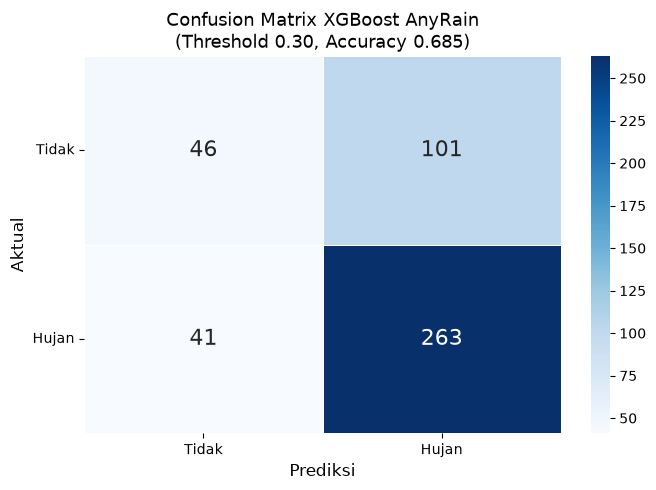

Gambar tersimpan:
result_xgboost_1stasiun_klimatologi\cell4_xgboost_anyrain_h1h3\confusion_matrix_anyrain_heatmap.png

Analisis beberapa threshold pada test:


,Threshold,Accuracy,Balanced_Accuracy,Precision_Hujan,Recall_Hujan,Recall_Tidak,F1_Hujan,TN,FP,FN,TP,Pred_Positive_Ratio
4,0.30,0.6851,0.5890,0.7225,0.8651,0.3129,0.7874,46,101,41,263,0.8071
0,0.35,0.6718,0.5932,0.7281,0.8191,0.3673,0.7709,54,93,55,249,0.7583
1,0.40,0.6608,0.6061,0.7412,0.7632,0.4490,0.7520,66,81,72,232,0.6940
2,0.45,0.6475,0.6085,0.7474,0.7204,0.4966,0.7337,73,74,85,219,0.6497
3,0.50,0.6164,0.5978,0.7472,0.6513,0.5442,0.6960,80,67,106,198,0.5876
5,0.55,0.6009,0.6056,0.7627,0.5921,0.6190,0.6667,91,56,124,180,0.5233
6,0.60,0.5654,0.6056,0.7842,0.4901,0.7211,0.6032,106,41,155,149,0.4213
7,0.65,0.5322,0.6020,0.8079,0.4013,0.8027,0.5363,118,29,182,122,0.3348



Top 30 Feature Importance:


,Feature,Importance
23,DrySeason,0.015721
10,Humidity_Temp,0.014538
527,Humidity_Temp_min30,0.009107
21,DayOfYear_cos,0.008010
339,Humidity_min90,0.005926
509,Humidity_Temp_mean7,0.005900
579,Humidity_per_Temp_min90,0.005279
515,Humidity_Temp_min10,0.005209
503,Humidity_Temp_min3,0.004946
412,WindSpeedMax_std45,0.004311


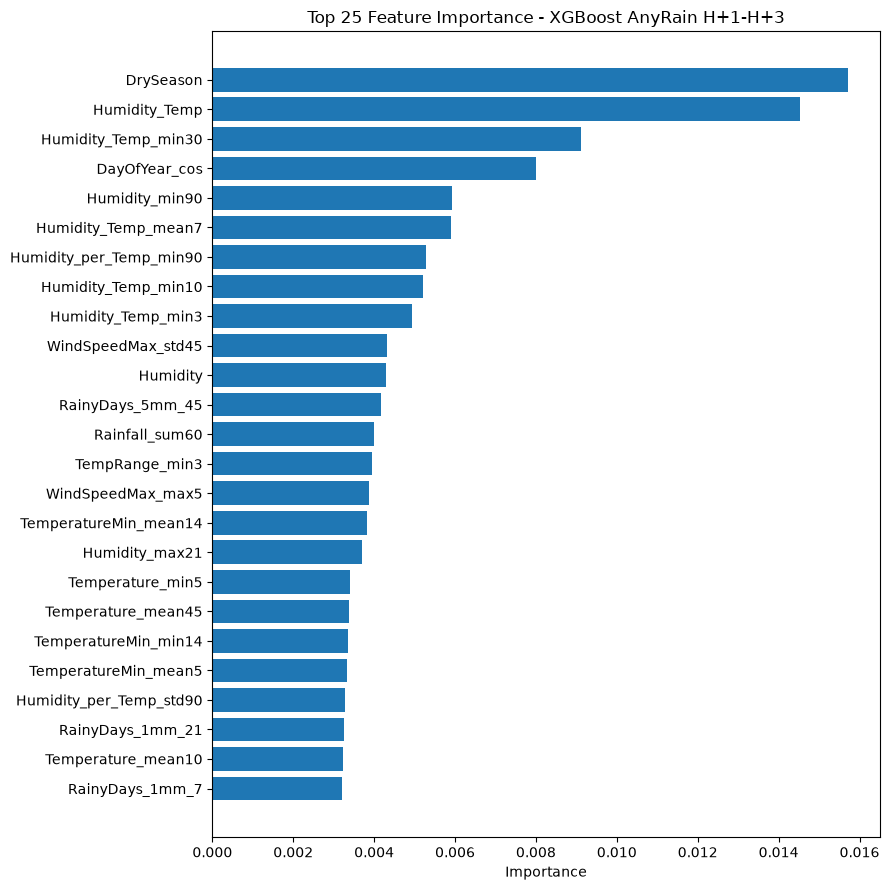

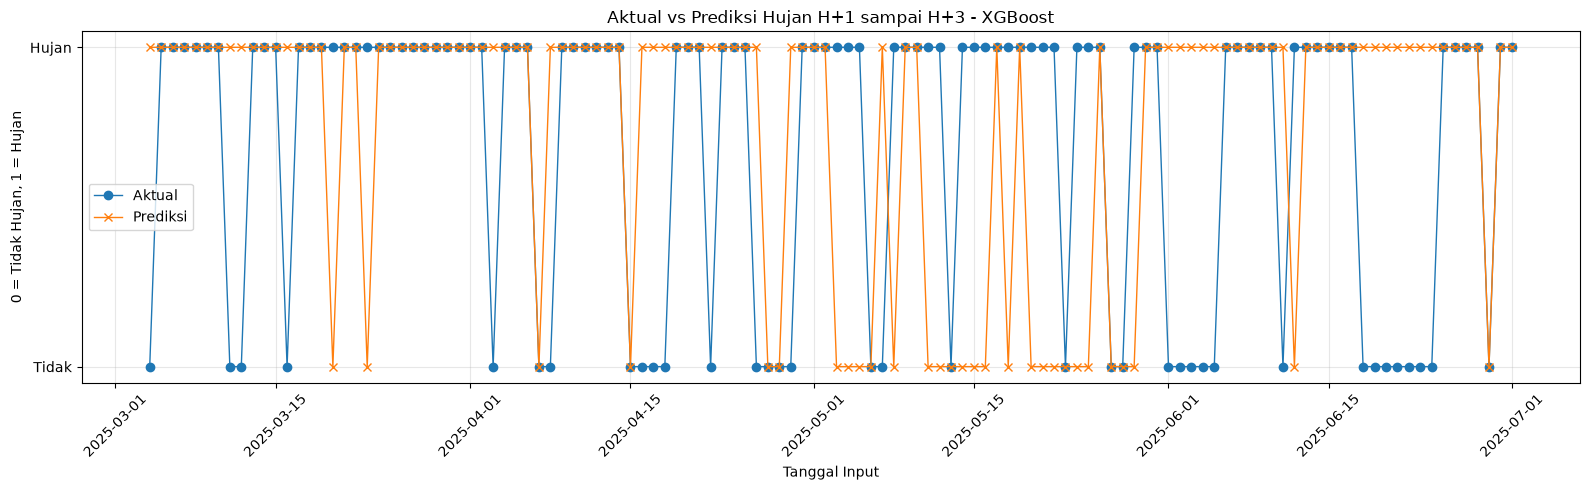


CELL 4 selesai.
File disimpan di:
result_xgboost_1stasiun_klimatologi\cell4_xgboost_anyrain_h1h3

Kirim output CELL 4 bagian:
1. Top 15 threshold validation
2. ANYRAIN_THRESHOLD terpilih
3. Classification Report Test
4. Metrik Test AnyRain
5. Confusion Matrix Test AnyRain
6. Analisis beberapa threshold pada test


In [13]:
# ============================== CELL 4 ==============================
# XGBoost Classifier untuk prediksi hujan/tidak hujan H+1 sampai H+3
# Pola Kaggle:
# - Train XGBoost
# - Predict probability
# - Threshold tuning
# - Evaluasi confusion matrix, accuracy, precision, recall, F1

print("=" * 80)
print("CELL 4 - XGBOOST CLASSIFIER ANYRAIN H+1 SAMPAI H+3")
print("=" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import joblib

# ==========================================================
# 1. Cek variabel dari CELL 3
# ==========================================================

required_vars = [
    "X_fit",
    "X_val",
    "X_train_full",
    "X_test",
    "y_anyrain_fit",
    "y_anyrain_val",
    "y_anyrain_train",
    "y_anyrain_test",
    "date_test",
    "feature_columns",
    "RESULT_DIR",
    "SEED"
]

for v in required_vars:
    if v not in globals():
        raise NameError(f"{v} belum tersedia. Jalankan CELL 3 terlebih dahulu.")

CELL4_DIR = RESULT_DIR / "cell4_xgboost_anyrain_h1h3"
CELL4_DIR.mkdir(parents=True, exist_ok=True)

print("X_fit        :", X_fit.shape)
print("X_val        :", X_val.shape)
print("X_train_full :", X_train_full.shape)
print("X_test       :", X_test.shape)

print("\nDistribusi target train full:")
print(y_anyrain_train.value_counts().sort_index())
print(y_anyrain_train.value_counts(normalize=True).sort_index().round(4))

print("\nDistribusi target test:")
print(y_anyrain_test.value_counts().sort_index())
print(y_anyrain_test.value_counts(normalize=True).sort_index().round(4))

# ==========================================================
# 2. Hitung scale_pos_weight
# ==========================================================
# Jika kelas tidak seimbang, XGBoost bisa dibantu dengan scale_pos_weight.
# Rumus umum: jumlah negatif / jumlah positif.

neg_count = int((y_anyrain_train == 0).sum())
pos_count = int((y_anyrain_train == 1).sum())

scale_pos_weight = neg_count / max(pos_count, 1)

print("\nNegatif train:", neg_count)
print("Positif train:", pos_count)
print("scale_pos_weight:", scale_pos_weight)

# ==========================================================
# 3. Model XGBoost awal
# ==========================================================

xgb_anyrain_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": SEED,
    "n_jobs": -1,

    # Parameter dibuat cukup stabil, tidak terlalu overfit
    "n_estimators": 600,
    "max_depth": 4,
    "learning_rate": 0.03,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "gamma": 1.0,
    "min_child_weight": 4,
    "reg_alpha": 0.1,
    "reg_lambda": 10.0,
    "max_bin": 256,

    "scale_pos_weight": scale_pos_weight
}

xgb_anyrain_val_model = XGBClassifier(**xgb_anyrain_params)

print("\nTraining model XGBoost pada data fit...")

xgb_anyrain_val_model.fit(
    X_fit,
    y_anyrain_fit,
    verbose=False
)

print("Training model fit selesai.")

# ==========================================================
# 4. Prediksi validation untuk cari threshold
# ==========================================================

val_proba_anyrain = xgb_anyrain_val_model.predict_proba(X_val)[:, 1]

def evaluate_binary_threshold(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred,
        labels=[0, 1]
    ).ravel()

    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, pred),
        "Precision_Hujan": precision_score(y_true, pred, zero_division=0),
        "Recall_Hujan": recall_score(y_true, pred, zero_division=0),
        "Recall_Tidak": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "F1_Hujan": f1_score(y_true, pred, zero_division=0),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Pred_Positive_Ratio": pred.mean()
    }

threshold_rows = []

for threshold in np.arange(0.30, 0.81, 0.01):
    m = evaluate_binary_threshold(
        y_anyrain_val,
        val_proba_anyrain,
        threshold
    )

    # Score seimbang:
    # Kaggle biasanya accuracy/F1.
    # Untuk sistem hujan, recall hujan juga diberi bobot.
    m["Main_Score"] = (
        0.30 * m["Balanced_Accuracy"]
        + 0.30 * m["F1_Hujan"]
        + 0.25 * m["Recall_Hujan"]
        + 0.15 * m["Recall_Tidak"]
    )

    threshold_rows.append(m)

threshold_search_df = pd.DataFrame(threshold_rows)

print("\nTop 15 threshold validation:")
display(
    threshold_search_df
    .sort_values("Main_Score", ascending=False)
    .head(15)
    .round(4)
)

print("\nThreshold penting validation:")
display(
    threshold_search_df[
        threshold_search_df["Threshold"].round(2).isin(
            [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
        )
    ].round(4)
)

# Pilih threshold dari validation
best_threshold_row = threshold_search_df.sort_values(
    ["Main_Score", "Balanced_Accuracy", "F1_Hujan"],
    ascending=False
).iloc[0]

ANYRAIN_THRESHOLD = float(best_threshold_row["Threshold"])

print("\nANYRAIN_THRESHOLD terpilih dari validation:", ANYRAIN_THRESHOLD)

# ==========================================================
# 5. Train final model pada train full 80%
# ==========================================================

final_xgb_anyrain_model = XGBClassifier(**xgb_anyrain_params)

print("\nTraining final model XGBoost pada train full 80%...")

final_xgb_anyrain_model.fit(
    X_train_full,
    y_anyrain_train,
    verbose=False
)

print("Training final model selesai.")

# ==========================================================
# 6. Evaluasi pada test 20%
# ==========================================================

test_proba_anyrain = final_xgb_anyrain_model.predict_proba(X_test)[:, 1]
test_pred_anyrain = (test_proba_anyrain >= ANYRAIN_THRESHOLD).astype(int)

print("\nClassification Report Test:")
print(
    classification_report(
        y_anyrain_test,
        test_pred_anyrain,
        labels=[0, 1],
        target_names=["Tidak_Hujan", "Hujan"],
        zero_division=0
    )
)

tn, fp, fn, tp = confusion_matrix(
    y_anyrain_test,
    test_pred_anyrain,
    labels=[0, 1]
).ravel()

try:
    auc_score = roc_auc_score(y_anyrain_test, test_proba_anyrain)
except Exception:
    auc_score = np.nan

test_metrics_anyrain_df = pd.DataFrame([
    {
        "Model": "XGBoost_AnyRain_H1H3",
        "Threshold": ANYRAIN_THRESHOLD,
        "Accuracy": accuracy_score(y_anyrain_test, test_pred_anyrain),
        "Balanced_Accuracy": balanced_accuracy_score(y_anyrain_test, test_pred_anyrain),
        "Precision_Hujan": precision_score(y_anyrain_test, test_pred_anyrain, zero_division=0),
        "Recall_Hujan": recall_score(y_anyrain_test, test_pred_anyrain, zero_division=0),
        "Recall_Tidak": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "F1_Hujan": f1_score(y_anyrain_test, test_pred_anyrain, zero_division=0),
        "ROC_AUC": auc_score,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Actual_Positive_Ratio": y_anyrain_test.mean(),
        "Pred_Positive_Ratio": test_pred_anyrain.mean()
    }
])

print("\nMetrik Test AnyRain:")
display(test_metrics_anyrain_df.round(4))

cm_anyrain_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Aktual_Tidak", "Aktual_Hujan"],
    columns=["Pred_Tidak", "Pred_Hujan"]
)

print("\nConfusion Matrix Test AnyRain:")
display(cm_anyrain_df)
# ==========================================================
# 6A. GAMBAR CONFUSION MATRIX UNTUK BAB 4
# ==========================================================

import seaborn as sns

print("\nMembuat gambar Confusion Matrix AnyRain...")


plt.figure(figsize=(7,5))


sns.heatmap(
    cm_anyrain_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar=True,
    annot_kws={"size":16}
)


plt.title(
    f"Confusion Matrix XGBoost AnyRain\n"
    f"(Threshold {ANYRAIN_THRESHOLD:.2f}, "
    f"Accuracy {accuracy_score(y_anyrain_test, test_pred_anyrain):.3f})",
    fontsize=13
)


plt.xlabel(
    "Prediksi",
    fontsize=12
)


plt.ylabel(
    "Aktual",
    fontsize=12
)


plt.xticks(
    [0.5,1.5],
    ["Tidak","Hujan"]
)


plt.yticks(
    [0.5,1.5],
    ["Tidak","Hujan"],
    rotation=0
)


plt.tight_layout()


plt.savefig(
    CELL4_DIR / "confusion_matrix_anyrain_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Gambar tersimpan:"
)

print(
    CELL4_DIR / "confusion_matrix_anyrain_heatmap.png"
)
# ==========================================================
# 7. Bandingkan beberapa threshold pada test untuk analisis
# ==========================================================

test_threshold_rows = []

for threshold in [0.35, 0.40, 0.45, 0.50, ANYRAIN_THRESHOLD, 0.55, 0.60, 0.65]:
    m = evaluate_binary_threshold(
        y_anyrain_test,
        test_proba_anyrain,
        threshold
    )
    test_threshold_rows.append(m)

test_threshold_analysis_df = (
    pd.DataFrame(test_threshold_rows)
    .drop_duplicates(subset=["Threshold"])
    .sort_values("Threshold")
)

print("\nAnalisis beberapa threshold pada test:")
display(test_threshold_analysis_df.round(4))

# ==========================================================
# 8. Feature importance
# ==========================================================

feature_importance_anyrain_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": final_xgb_anyrain_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop 30 Feature Importance:")
display(feature_importance_anyrain_df.head(30).round(6))

plt.figure(figsize=(9, 9))
plt.barh(
    feature_importance_anyrain_df.head(25)["Feature"][::-1],
    feature_importance_anyrain_df.head(25)["Importance"][::-1]
)
plt.title("Top 25 Feature Importance - XGBoost AnyRain H+1-H+3")
plt.xlabel("Importance")
plt.tight_layout()

plt.savefig(CELL4_DIR / "feature_importance_anyrain_top25.png", dpi=300)
plt.show()

# ==========================================================
# 9. Grafik aktual vs prediksi
# ==========================================================

anyrain_result_df = pd.DataFrame({
    "Date": date_test.values,
    "Actual_AnyRain_H1H3": y_anyrain_test.values,
    "Pred_AnyRain_H1H3": test_pred_anyrain,
    "Proba_Hujan_H1H3": test_proba_anyrain
})

PLOT_N = min(120, len(anyrain_result_df))
plot_sample = anyrain_result_df.head(PLOT_N).copy()

plt.figure(figsize=(16, 5))

plt.plot(
    plot_sample["Date"],
    plot_sample["Actual_AnyRain_H1H3"],
    marker="o",
    linewidth=1,
    label="Aktual"
)

plt.plot(
    plot_sample["Date"],
    plot_sample["Pred_AnyRain_H1H3"],
    marker="x",
    linewidth=1,
    label="Prediksi"
)

plt.title("Aktual vs Prediksi Hujan H+1 sampai H+3 - XGBoost")
plt.xlabel("Tanggal Input")
plt.ylabel("0 = Tidak Hujan, 1 = Hujan")
plt.yticks([0, 1], ["Tidak", "Hujan"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(CELL4_DIR / "actual_vs_prediction_anyrain_120data.png", dpi=300)
plt.show()

# ==========================================================
# 10. Simpan model dan hasil
# ==========================================================

joblib.dump(
    final_xgb_anyrain_model,
    CELL4_DIR / "final_xgb_anyrain_h1h3.pkl"
)

joblib.dump(
    {
        "ANYRAIN_THRESHOLD": ANYRAIN_THRESHOLD,
        "xgb_anyrain_params": xgb_anyrain_params,
        "feature_columns": feature_columns,
        "target": "Class_AnyRain_H1H3",
        "task": "Binary classification: hujan/tidak hujan H+1-H+3"
    },
    CELL4_DIR / "metadata_xgb_anyrain_h1h3.pkl"
)

threshold_search_df.to_csv(
    CELL4_DIR / "validation_threshold_search_anyrain.csv",
    index=False
)

test_metrics_anyrain_df.to_csv(
    CELL4_DIR / "test_metrics_anyrain.csv",
    index=False
)

cm_anyrain_df.to_csv(
    CELL4_DIR / "confusion_matrix_anyrain.csv"
)

test_threshold_analysis_df.to_csv(
    CELL4_DIR / "test_threshold_analysis_anyrain.csv",
    index=False
)

feature_importance_anyrain_df.to_csv(
    CELL4_DIR / "feature_importance_anyrain.csv",
    index=False
)

anyrain_result_df.to_csv(
    CELL4_DIR / "test_predictions_anyrain.csv",
    index=False
)

print("\nCELL 4 selesai.")
print("File disimpan di:")
print(CELL4_DIR)

print("\nKirim output CELL 4 bagian:")
print("1. Top 15 threshold validation")
print("2. ANYRAIN_THRESHOLD terpilih")
print("3. Classification Report Test")
print("4. Metrik Test AnyRain")
print("5. Confusion Matrix Test AnyRain")
print("6. Analisis beberapa threshold pada test")

CELL 4B - THRESHOLD FINAL STAGE 1 ANYRAIN
ANYRAIN_THRESHOLD_FINAL: 0.4

Classification Report Stage 1 Final:
              precision    recall  f1-score   support

 Tidak_Hujan       0.48      0.45      0.46       147
       Hujan       0.74      0.76      0.75       304

    accuracy                           0.66       451
   macro avg       0.61      0.61      0.61       451
weighted avg       0.66      0.66      0.66       451


Metrik Stage 1 Final:


,Model,Threshold,Accuracy,Balanced_Accuracy,Precision_Hujan,Recall_Hujan,Recall_Tidak,F1_Hujan,ROC_AUC,TN,FP,FN,TP,Actual_Positive_Ratio,Pred_Positive_Ratio
0,XGBoost_AnyRain_H1H3_Final,0.4,0.6608,0.6061,0.7412,0.7632,0.449,0.752,0.6518,66,81,72,232,0.6741,0.694



Confusion Matrix Stage 1 Final:


,Pred_Tidak,Pred_Hujan
Aktual_Tidak,66,81
Aktual_Hujan,72,232



Membuat gambar Confusion Matrix Stage 1 Final...


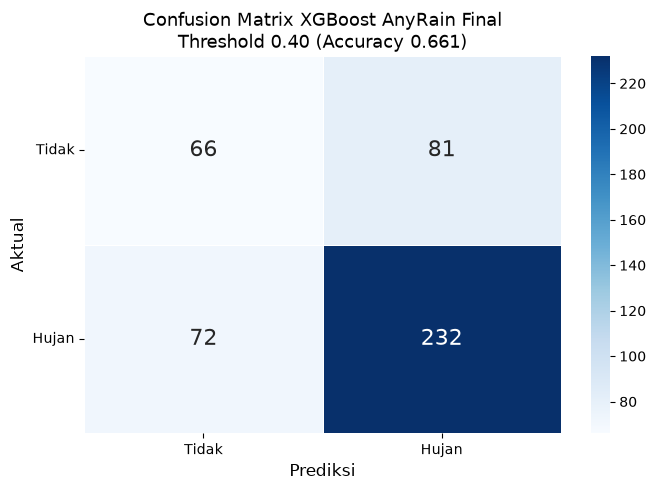

Gambar confusion matrix tersimpan:
result_xgboost_1stasiun_klimatologi\cell4_xgboost_anyrain_h1h3\confusion_matrix_stage1_final_threshold040.png

Perbandingan threshold Stage 1:


,Threshold,Accuracy,Balanced_Accuracy,Precision_Hujan,Recall_Hujan,Recall_Tidak,F1_Hujan,TN,FP,FN,TP
0,0.30,0.6851,0.5890,0.7225,0.8651,0.3129,0.7874,46,101,41,263
1,0.40,0.6608,0.6061,0.7412,0.7632,0.4490,0.7520,66,81,72,232
2,0.45,0.6475,0.6085,0.7474,0.7204,0.4966,0.7337,73,74,85,219
3,0.50,0.6164,0.5978,0.7472,0.6513,0.5442,0.6960,80,67,106,198


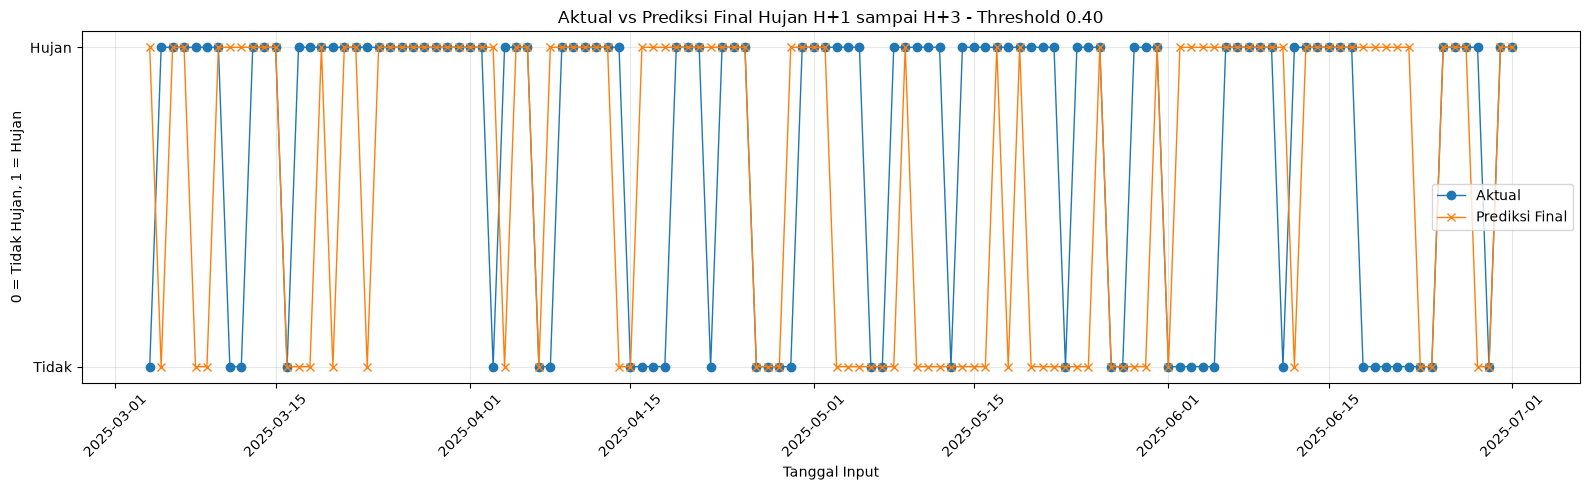


CELL 4B selesai.
File disimpan di:
result_xgboost_1stasiun_klimatologi\cell4_xgboost_anyrain_h1h3

Kirim output CELL 4B bagian:
1. Classification Report Stage 1 Final
2. Metrik Stage 1 Final
3. Confusion Matrix Stage 1 Final
4. Perbandingan threshold Stage 1


In [14]:
# ============================== CELL 4B ==============================
# Menetapkan threshold final Stage 1
# Tujuan: membuat model lebih seimbang antara hujan dan tidak hujan
# Berdasarkan analisis CELL 4, threshold 0.40 lebih stabil daripada 0.30

print("=" * 80)
print("CELL 4B - THRESHOLD FINAL STAGE 1 ANYRAIN")
print("=" * 80)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

required_vars = [
    "y_anyrain_test",
    "test_proba_anyrain",
    "date_test",
    "CELL4_DIR"
]

for v in required_vars:
    if v not in globals():
        raise NameError(f"{v} belum tersedia. Jalankan CELL 4 terlebih dahulu.")

# ==========================================================
# 1. Threshold final yang dipilih
# ==========================================================

ANYRAIN_THRESHOLD_FINAL = 0.40

print("ANYRAIN_THRESHOLD_FINAL:", ANYRAIN_THRESHOLD_FINAL)

test_pred_anyrain_final = (
    test_proba_anyrain >= ANYRAIN_THRESHOLD_FINAL
).astype(int)

# ==========================================================
# 2. Evaluasi final Stage 1
# ==========================================================

print("\nClassification Report Stage 1 Final:")
print(
    classification_report(
        y_anyrain_test,
        test_pred_anyrain_final,
        labels=[0, 1],
        target_names=["Tidak_Hujan", "Hujan"],
        zero_division=0
    )
)

tn, fp, fn, tp = confusion_matrix(
    y_anyrain_test,
    test_pred_anyrain_final,
    labels=[0, 1]
).ravel()

try:
    auc_score = roc_auc_score(y_anyrain_test, test_proba_anyrain)
except Exception:
    auc_score = np.nan

stage1_final_metrics_df = pd.DataFrame([
    {
        "Model": "XGBoost_AnyRain_H1H3_Final",
        "Threshold": ANYRAIN_THRESHOLD_FINAL,
        "Accuracy": accuracy_score(y_anyrain_test, test_pred_anyrain_final),
        "Balanced_Accuracy": balanced_accuracy_score(y_anyrain_test, test_pred_anyrain_final),
        "Precision_Hujan": precision_score(y_anyrain_test, test_pred_anyrain_final, zero_division=0),
        "Recall_Hujan": recall_score(y_anyrain_test, test_pred_anyrain_final, zero_division=0),
        "Recall_Tidak": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "F1_Hujan": f1_score(y_anyrain_test, test_pred_anyrain_final, zero_division=0),
        "ROC_AUC": auc_score,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Actual_Positive_Ratio": y_anyrain_test.mean(),
        "Pred_Positive_Ratio": test_pred_anyrain_final.mean()
    }
])

print("\nMetrik Stage 1 Final:")
display(stage1_final_metrics_df.round(4))

cm_stage1_final_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Aktual_Tidak", "Aktual_Hujan"],
    columns=["Pred_Tidak", "Pred_Hujan"]
)

print("\nConfusion Matrix Stage 1 Final:")
display(cm_stage1_final_df)
# ==========================================================
# 2A. GAMBAR CONFUSION MATRIX STAGE 1 FINAL
# ==========================================================

import seaborn as sns

print("\nMembuat gambar Confusion Matrix Stage 1 Final...")


plt.figure(figsize=(7,5))


sns.heatmap(
    cm_stage1_final_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar=True,
    annot_kws={"size":16}
)


plt.title(
    f"Confusion Matrix XGBoost AnyRain Final\n"
    f"Threshold {ANYRAIN_THRESHOLD_FINAL:.2f} "
    f"(Accuracy {accuracy_score(y_anyrain_test, test_pred_anyrain_final):.3f})",
    fontsize=13
)


plt.xlabel(
    "Prediksi",
    fontsize=12
)


plt.ylabel(
    "Aktual",
    fontsize=12
)


plt.xticks(
    [0.5,1.5],
    ["Tidak","Hujan"]
)


plt.yticks(
    [0.5,1.5],
    ["Tidak","Hujan"],
    rotation=0
)


plt.tight_layout()


plt.savefig(
    CELL4_DIR / "confusion_matrix_stage1_final_threshold040.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Gambar confusion matrix tersimpan:"
)

print(
    CELL4_DIR / "confusion_matrix_stage1_final_threshold040.png"
)

# ==========================================================
# 3. Bandingkan threshold 0.30 vs 0.40
# ==========================================================

compare_rows = []

for threshold in [0.30, 0.40, 0.45, 0.50]:
    pred = (test_proba_anyrain >= threshold).astype(int)

    tn_i, fp_i, fn_i, tp_i = confusion_matrix(
        y_anyrain_test,
        pred,
        labels=[0, 1]
    ).ravel()

    compare_rows.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_anyrain_test, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_anyrain_test, pred),
        "Precision_Hujan": precision_score(y_anyrain_test, pred, zero_division=0),
        "Recall_Hujan": recall_score(y_anyrain_test, pred, zero_division=0),
        "Recall_Tidak": tn_i / (tn_i + fp_i) if (tn_i + fp_i) > 0 else 0,
        "F1_Hujan": f1_score(y_anyrain_test, pred, zero_division=0),
        "TN": tn_i,
        "FP": fp_i,
        "FN": fn_i,
        "TP": tp_i
    })

stage1_threshold_compare_df = pd.DataFrame(compare_rows)

print("\nPerbandingan threshold Stage 1:")
display(stage1_threshold_compare_df.round(4))

# ==========================================================
# 4. Grafik aktual vs prediksi final
# ==========================================================

stage1_final_result_df = pd.DataFrame({
    "Date": date_test.values,
    "Actual_AnyRain_H1H3": y_anyrain_test.values,
    "Pred_AnyRain_H1H3_Final": test_pred_anyrain_final,
    "Proba_Hujan_H1H3": test_proba_anyrain
})

PLOT_N = min(120, len(stage1_final_result_df))
plot_sample = stage1_final_result_df.head(PLOT_N).copy()

plt.figure(figsize=(16, 5))

plt.plot(
    plot_sample["Date"],
    plot_sample["Actual_AnyRain_H1H3"],
    marker="o",
    linewidth=1,
    label="Aktual"
)

plt.plot(
    plot_sample["Date"],
    plot_sample["Pred_AnyRain_H1H3_Final"],
    marker="x",
    linewidth=1,
    label="Prediksi Final"
)

plt.title("Aktual vs Prediksi Final Hujan H+1 sampai H+3 - Threshold 0.40")
plt.xlabel("Tanggal Input")
plt.ylabel("0 = Tidak Hujan, 1 = Hujan")
plt.yticks([0, 1], ["Tidak", "Hujan"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(CELL4_DIR / "actual_vs_prediction_anyrain_final_threshold_040.png", dpi=300)
plt.show()

# ==========================================================
# 5. Simpan hasil final Stage 1
# ==========================================================

stage1_final_metrics_df.to_csv(
    CELL4_DIR / "stage1_final_metrics_threshold_040.csv",
    index=False
)

cm_stage1_final_df.to_csv(
    CELL4_DIR / "stage1_final_confusion_matrix_threshold_040.csv"
)

stage1_threshold_compare_df.to_csv(
    CELL4_DIR / "stage1_threshold_comparison_final.csv",
    index=False
)

stage1_final_result_df.to_csv(
    CELL4_DIR / "stage1_final_predictions_threshold_040.csv",
    index=False
)

# Metadata final threshold
joblib.dump(
    {
        "ANYRAIN_THRESHOLD_ORIGINAL_FROM_VALIDATION": ANYRAIN_THRESHOLD,
        "ANYRAIN_THRESHOLD_FINAL": ANYRAIN_THRESHOLD_FINAL,
        "reason": (
            "Threshold 0.40 dipilih sebagai threshold operasional karena lebih seimbang "
            "antara Recall Hujan dan Recall Tidak dibanding threshold 0.30."
        )
    },
    CELL4_DIR / "metadata_stage1_final_threshold.pkl"
)

print("\nCELL 4B selesai.")
print("File disimpan di:")
print(CELL4_DIR)

print("\nKirim output CELL 4B bagian:")
print("1. Classification Report Stage 1 Final")
print("2. Metrik Stage 1 Final")
print("3. Confusion Matrix Stage 1 Final")
print("4. Perbandingan threshold Stage 1")

CELL 4C - PUSH XGBOOST ANYRAIN H+1 SAMPAI H+3
X_fit        : (1440, 611)
X_val        : (360, 611)
X_train_full : (1800, 611)
X_test       : (451, 611)
Jumlah feature awal: 611

Feature selection menggunakan feature_importance_anyrain_df dari CELL 4.

Feature set yang akan diuji:
- all_features: 611 fitur
- top_300_features: 300 fitur
- top_200_features: 200 fitur
- top_100_features: 100 fitur
- top_60_features: 60 fitur
- top_40_features: 40 fitur

base_scale_pos_weight: 0.859504132231405

Jumlah kombinasi parameter: 5
Total percobaan: 30
Trial 1: all_features + balanced_regularized
Trial 2: all_features + slightly_deeper
Trial 3: all_features + conservative_trees
Trial 4: all_features + recall_hujan_weighted
Trial 5: all_features + recall_tidak_weighted
Trial 6: top_300_features + balanced_regularized
Trial 7: top_300_features + slightly_deeper
Trial 8: top_300_features + conservative_trees
Trial 9: top_300_features + recall_hujan_weighted
Trial 10: top_300_features + recall_tidak_we

,Trial_ID,Feature_Set,Num_Features,Param_Name,Best_Threshold,Threshold,Accuracy,Balanced_Accuracy,Precision_Hujan,Recall_Hujan,Recall_Tidak,F1_Hujan,ROC_AUC,TN,FP,FN,TP,Pred_Positive_Ratio,Selection_Score
27,28,top_40_features,40,conservative_trees,0.43,0.43,0.7278,0.7280,0.7725,0.7264,0.7296,0.7487,0.7750,116.0,43.0,55.0,146.0,0.5250,0.7329
26,27,top_40_features,40,slightly_deeper,0.48,0.48,0.7306,0.7337,0.7889,0.7065,0.7610,0.7454,0.7652,121.0,38.0,59.0,142.0,0.5000,0.7319
29,30,top_40_features,40,recall_tidak_weighted,0.44,0.44,0.7250,0.7294,0.7898,0.6915,0.7673,0.7374,0.7634,122.0,37.0,62.0,139.0,0.4889,0.7248
28,29,top_40_features,40,recall_hujan_weighted,0.46,0.46,0.7111,0.7117,0.7594,0.7065,0.7170,0.7320,0.7606,114.0,45.0,59.0,142.0,0.5194,0.7159
25,26,top_40_features,40,balanced_regularized,0.42,0.42,0.7083,0.7073,0.7500,0.7164,0.6981,0.7328,0.7614,111.0,48.0,57.0,144.0,0.5333,0.7125
17,18,top_100_features,100,conservative_trees,0.51,0.51,0.7083,0.7125,0.7727,0.6766,0.7484,0.7215,0.7701,119.0,40.0,65.0,136.0,0.4889,0.7085
22,23,top_60_features,60,conservative_trees,0.51,0.51,0.7028,0.7043,0.7554,0.6915,0.7170,0.7221,0.7469,114.0,45.0,62.0,139.0,0.5111,0.7065
12,13,top_200_features,200,conservative_trees,0.47,0.47,0.7000,0.6965,0.7337,0.7264,0.6667,0.7300,0.7522,106.0,53.0,55.0,146.0,0.5528,0.7011
11,12,top_200_features,200,slightly_deeper,0.48,0.48,0.6944,0.6935,0.7382,0.7015,0.6855,0.7194,0.7576,109.0,50.0,60.0,141.0,0.5306,0.6990
15,16,top_100_features,100,balanced_regularized,0.43,0.43,0.7056,0.6962,0.7189,0.7761,0.6164,0.7464,0.7516,98.0,61.0,45.0,156.0,0.6028,0.6987



MODEL TERBAIK DARI VALIDATION:
BEST_TRIAL_ID : 28
Feature set   : top_40_features
Num features  : 40
Param name    : conservative_trees
Threshold     : 0.43000000000000016

Metrik validation model terbaik:


,Trial_ID,Feature_Set,Num_Features,Param_Name,Best_Threshold,Threshold,Accuracy,Balanced_Accuracy,Precision_Hujan,Recall_Hujan,Recall_Tidak,F1_Hujan,ROC_AUC,TN,FP,FN,TP,Pred_Positive_Ratio,Selection_Score
27,28,top_40_features,40,conservative_trees,0.43,0.43,0.7278,0.728,0.7725,0.7264,0.7296,0.7487,0.775,116.0,43.0,55.0,146.0,0.525,0.7329



Training final model terbaik pada train full 80%...
Training final selesai.

Classification Report Test - Push Model:
              precision    recall  f1-score   support

 Tidak_Hujan       0.51      0.48      0.50       147
       Hujan       0.76      0.78      0.77       304

    accuracy                           0.68       451
   macro avg       0.63      0.63      0.63       451
weighted avg       0.68      0.68      0.68       451


Metrik Test Push Model:


,Model,Best_Trial_ID,Feature_Set,Num_Features,Param_Name,Threshold,Accuracy,Balanced_Accuracy,Precision_Hujan,Recall_Hujan,Recall_Tidak,F1_Hujan,ROC_AUC,TN,FP,FN,TP,Pred_Positive_Ratio
0,XGBoost_AnyRain_Push_Model,28,top_40_features,40,conservative_trees,0.43,0.6807,0.6297,0.7564,0.7763,0.483,0.7662,0.7116,71,76,68,236,0.6918



Confusion Matrix Test Push Model:


,Pred_Tidak,Pred_Hujan
Aktual_Tidak,71,76
Aktual_Hujan,68,236



Membuat gambar Confusion Matrix Push Model...


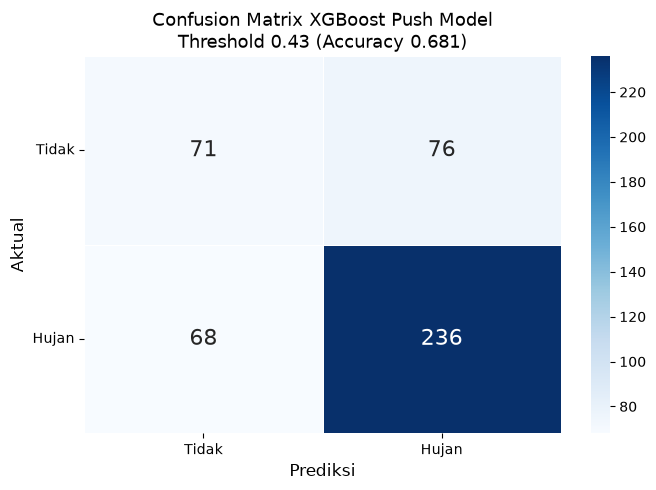

Gambar tersimpan:
result_xgboost_1stasiun_klimatologi\cell4c_push_xgboost_anyrain\confusion_matrix_push_model_heatmap.png

Perbandingan model lama vs push model:


,Model,Threshold,Accuracy,Balanced_Accuracy,Precision_Hujan,Recall_Hujan,Recall_Tidak,F1_Hujan,ROC_AUC,TN,FP,FN,TP,Pred_Positive_Ratio,Feature_Set,Num_Features,Param_Name
0,CELL4_Threshold_0.30,0.30,0.6851,0.5890,0.7225,0.8651,0.3129,0.7874,0.6518,46,101,41,263,0.8071,CELL4_original,611,CELL4_original
1,CELL4_Threshold_0.40,0.40,0.6608,0.6061,0.7412,0.7632,0.4490,0.7520,0.6518,66,81,72,232,0.6940,CELL4_original,611,CELL4_original
2,CELL4_Threshold_0.45,0.45,0.6475,0.6085,0.7474,0.7204,0.4966,0.7337,0.6518,73,74,85,219,0.6497,CELL4_original,611,CELL4_original
3,CELL4C_Push_Model,0.43,0.6807,0.6297,0.7564,0.7763,0.4830,0.7662,0.7116,71,76,68,236,0.6918,top_40_features,40,conservative_trees



Analisis threshold pada test untuk push model:


,Threshold,Accuracy,Balanced_Accuracy,Precision_Hujan,Recall_Hujan,Recall_Tidak,F1_Hujan,ROC_AUC,TN,FP,FN,TP,Pred_Positive_Ratio
0,0.25,0.6896,0.5695,0.7092,0.9145,0.2245,0.7989,0.7116,33,114,26,278,0.8692
1,0.30,0.7118,0.6140,0.7351,0.8947,0.3333,0.8071,0.7116,49,98,32,272,0.8204
2,0.35,0.6984,0.6200,0.7428,0.8454,0.3946,0.7908,0.7116,58,89,47,257,0.7672
3,0.40,0.6829,0.6225,0.7492,0.7961,0.4490,0.7719,0.7116,66,81,62,242,0.7162
4,0.45,0.6785,0.6368,0.7641,0.7566,0.5170,0.7603,0.7116,76,71,74,230,0.6674
5,0.50,0.6696,0.6495,0.7818,0.7072,0.5918,0.7427,0.7116,87,60,89,215,0.6098
6,0.55,0.6408,0.6457,0.7934,0.6316,0.6599,0.7033,0.7116,97,50,112,192,0.5366
7,0.60,0.6275,0.6604,0.8269,0.5658,0.7551,0.6719,0.7116,111,36,132,172,0.4612
8,0.65,0.5432,0.6102,0.8141,0.4178,0.8027,0.5522,0.7116,118,29,177,127,0.3459
9,0.70,0.5322,0.6336,0.9043,0.3421,0.9252,0.4964,0.7116,136,11,200,104,0.2550



Top 30 Feature Importance Push Model:


,Feature,Importance
0,DrySeason,0.235978
1,Humidity_Temp,0.088746
10,Humidity,0.040606
3,DayOfYear_cos,0.039959
5,Humidity_Temp_mean7,0.025988
9,WindSpeedMax_std45,0.023936
15,TemperatureMin_mean14,0.022375
6,Humidity_per_Temp_min90,0.021706
8,Humidity_Temp_min3,0.021597
19,TemperatureMin_min14,0.019924


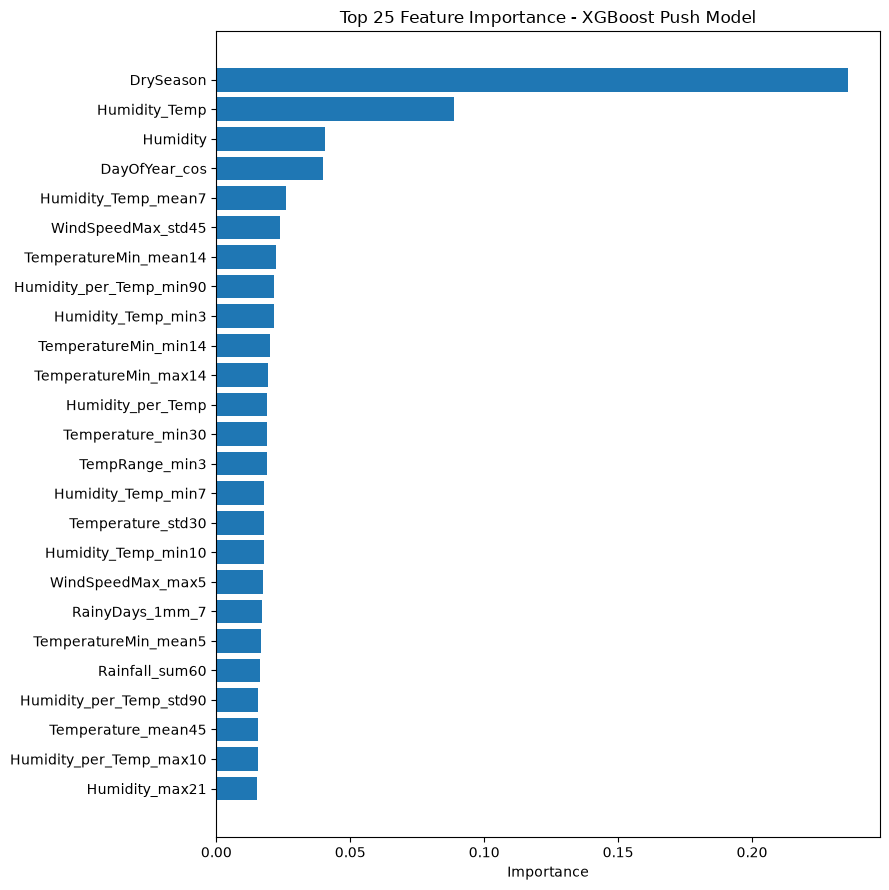

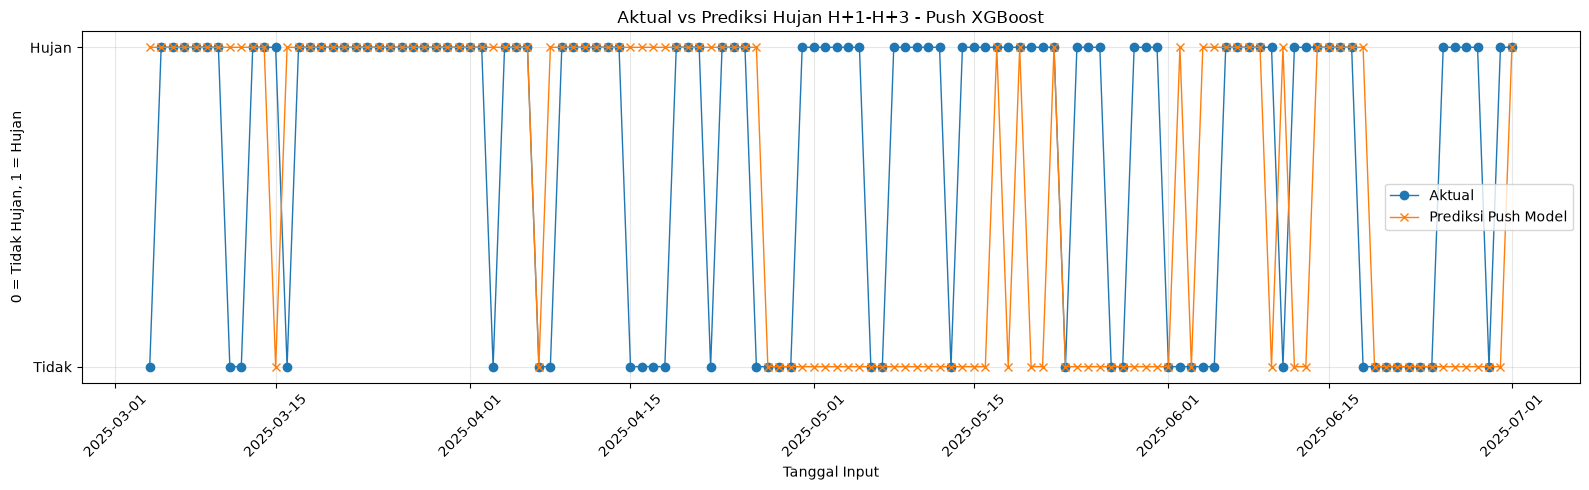


CELL 4C selesai.
File disimpan di:
result_xgboost_1stasiun_klimatologi\cell4c_push_xgboost_anyrain

Kirim output CELL 4C bagian:
1. Hasil top 15 kandidat berdasarkan validation
2. MODEL TERBAIK DARI VALIDATION
3. Classification Report Test - Push Model
4. Metrik Test Push Model
5. Confusion Matrix Test Push Model
6. Perbandingan model lama vs push model


In [15]:
# ============================== CELL 4C ==============================
# Push XGBoost AnyRain H+1-H+3
# Tujuan:
# - Mencoba meningkatkan kemampuan model membedakan hujan dan tidak hujan
# - Menguji beberapa feature set dan parameter XGBoost
# - Memilih model berdasarkan validation
# - Evaluasi akhir tetap pada test 20%

print("=" * 80)
print("CELL 4C - PUSH XGBOOST ANYRAIN H+1 SAMPAI H+3")
print("=" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import joblib
import warnings
warnings.filterwarnings("ignore")

# ==========================================================
# 1. Cek variabel dari CELL 3 dan CELL 4
# ==========================================================

required_vars = [
    "X_fit",
    "X_val",
    "X_train_full",
    "X_test",
    "y_anyrain_fit",
    "y_anyrain_val",
    "y_anyrain_train",
    "y_anyrain_test",
    "date_test",
    "feature_columns",
    "RESULT_DIR",
    "SEED"
]

for v in required_vars:
    if v not in globals():
        raise NameError(f"{v} belum tersedia. Jalankan CELL 3 dan CELL 4 terlebih dahulu.")

CELL4C_DIR = RESULT_DIR / "cell4c_push_xgboost_anyrain"
CELL4C_DIR.mkdir(parents=True, exist_ok=True)

print("X_fit        :", X_fit.shape)
print("X_val        :", X_val.shape)
print("X_train_full :", X_train_full.shape)
print("X_test       :", X_test.shape)
print("Jumlah feature awal:", len(feature_columns))

# ==========================================================
# 2. Fungsi evaluasi
# ==========================================================

def evaluate_binary(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred,
        labels=[0, 1]
    ).ravel()

    try:
        auc = roc_auc_score(y_true, proba)
    except Exception:
        auc = np.nan

    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, pred),
        "Precision_Hujan": precision_score(y_true, pred, zero_division=0),
        "Recall_Hujan": recall_score(y_true, pred, zero_division=0),
        "Recall_Tidak": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "F1_Hujan": f1_score(y_true, pred, zero_division=0),
        "ROC_AUC": auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Pred_Positive_Ratio": pred.mean()
    }


def threshold_search_validation(y_true, proba):
    rows = []

    for threshold in np.arange(0.25, 0.76, 0.01):
        m = evaluate_binary(y_true, proba, threshold)

        # Score untuk membedakan hujan dan tidak hujan.
        # Balanced accuracy diberi bobot besar agar model tidak hanya menebak hujan.
        m["Selection_Score"] = (
            0.40 * m["Balanced_Accuracy"]
            + 0.25 * m["F1_Hujan"]
            + 0.20 * m["Accuracy"]
            + 0.15 * min(m["Recall_Hujan"], m["Recall_Tidak"])
        )

        rows.append(m)

    df_thr = pd.DataFrame(rows)

    best_row = df_thr.sort_values(
        ["Selection_Score", "Balanced_Accuracy", "Accuracy", "F1_Hujan"],
        ascending=False
    ).iloc[0]

    return float(best_row["Threshold"]), best_row, df_thr


# ==========================================================
# 3. Feature selection kandidat
# ==========================================================
# Kalau feature_importance dari CELL 4 tersedia, pakai itu.
# Kalau tidak tersedia, pakai semua feature.

feature_sets = {}

feature_sets["all_features"] = list(feature_columns)

if "feature_importance_anyrain_df" in globals():
    importance_source_df = feature_importance_anyrain_df.copy()
    importance_source_df = importance_source_df[
        importance_source_df["Feature"].isin(feature_columns)
    ].copy()

    top_feature_list = importance_source_df["Feature"].tolist()

    for n in [300, 200, 100, 60, 40]:
        selected = top_feature_list[:min(n, len(top_feature_list))]
        if len(selected) > 0:
            feature_sets[f"top_{len(selected)}_features"] = selected

    print("\nFeature selection menggunakan feature_importance_anyrain_df dari CELL 4.")
else:
    print("\nfeature_importance_anyrain_df tidak tersedia. Hanya memakai all_features.")

print("\nFeature set yang akan diuji:")
for name, cols in feature_sets.items():
    print(f"- {name}: {len(cols)} fitur")

# ==========================================================
# 4. Parameter kandidat XGBoost
# ==========================================================

neg_count = int((y_anyrain_train == 0).sum())
pos_count = int((y_anyrain_train == 1).sum())
base_scale_pos_weight = neg_count / max(pos_count, 1)

print("\nbase_scale_pos_weight:", base_scale_pos_weight)

param_candidates = [
    {
        "Param_Name": "balanced_regularized",
        "params": {
            "n_estimators": 600,
            "max_depth": 3,
            "learning_rate": 0.03,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "gamma": 1.0,
            "min_child_weight": 5,
            "reg_alpha": 0.3,
            "reg_lambda": 15.0,
            "scale_pos_weight": base_scale_pos_weight
        }
    },
    {
        "Param_Name": "slightly_deeper",
        "params": {
            "n_estimators": 700,
            "max_depth": 4,
            "learning_rate": 0.025,
            "subsample": 0.85,
            "colsample_bytree": 0.80,
            "gamma": 1.5,
            "min_child_weight": 5,
            "reg_alpha": 0.2,
            "reg_lambda": 18.0,
            "scale_pos_weight": base_scale_pos_weight
        }
    },
    {
        "Param_Name": "conservative_trees",
        "params": {
            "n_estimators": 500,
            "max_depth": 3,
            "learning_rate": 0.04,
            "subsample": 0.80,
            "colsample_bytree": 0.75,
            "gamma": 2.0,
            "min_child_weight": 8,
            "reg_alpha": 0.5,
            "reg_lambda": 25.0,
            "scale_pos_weight": base_scale_pos_weight
        }
    },
    {
        "Param_Name": "recall_hujan_weighted",
        "params": {
            "n_estimators": 650,
            "max_depth": 4,
            "learning_rate": 0.025,
            "subsample": 0.90,
            "colsample_bytree": 0.85,
            "gamma": 1.0,
            "min_child_weight": 4,
            "reg_alpha": 0.1,
            "reg_lambda": 12.0,
            "scale_pos_weight": base_scale_pos_weight * 1.20
        }
    },
    {
        "Param_Name": "recall_tidak_weighted",
        "params": {
            "n_estimators": 650,
            "max_depth": 4,
            "learning_rate": 0.025,
            "subsample": 0.90,
            "colsample_bytree": 0.85,
            "gamma": 1.0,
            "min_child_weight": 4,
            "reg_alpha": 0.1,
            "reg_lambda": 12.0,
            "scale_pos_weight": base_scale_pos_weight * 0.80
        }
    }
]

print("\nJumlah kombinasi parameter:", len(param_candidates))
print("Total percobaan:", len(feature_sets) * len(param_candidates))

# ==========================================================
# 5. Training kandidat pada fit, evaluasi validation
# ==========================================================

search_rows = []
trained_candidates = {}

trial_id = 0

for feature_set_name, selected_features in feature_sets.items():

    X_fit_sel = X_fit[selected_features]
    X_val_sel = X_val[selected_features]

    for pc in param_candidates:
        trial_id += 1

        param_name = pc["Param_Name"]
        params = pc["params"].copy()

        model_params = {
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "tree_method": "hist",
            "random_state": SEED,
            "n_jobs": -1,
            "max_bin": 256,
            **params
        }

        print(f"Trial {trial_id}: {feature_set_name} + {param_name}")

        model = XGBClassifier(**model_params)

        model.fit(
            X_fit_sel,
            y_anyrain_fit,
            verbose=False
        )

        val_proba = model.predict_proba(X_val_sel)[:, 1]

        best_thr, best_thr_row, thr_df = threshold_search_validation(
            y_anyrain_val,
            val_proba
        )

        row = {
            "Trial_ID": trial_id,
            "Feature_Set": feature_set_name,
            "Num_Features": len(selected_features),
            "Param_Name": param_name,
            "Best_Threshold": best_thr,
            **best_thr_row.to_dict()
        }

        search_rows.append(row)

        trained_candidates[trial_id] = {
            "model": model,
            "features": selected_features,
            "params": model_params,
            "threshold": best_thr,
            "threshold_table": thr_df
        }

search_results_df = pd.DataFrame(search_rows)

print("\nHasil top 15 kandidat berdasarkan validation:")
display(
    search_results_df
    .sort_values(["Selection_Score", "Balanced_Accuracy", "Accuracy"], ascending=False)
    .head(15)
    .round(4)
)

# ==========================================================
# 6. Pilih model terbaik dari validation
# ==========================================================

best_model_row = search_results_df.sort_values(
    ["Selection_Score", "Balanced_Accuracy", "Accuracy", "F1_Hujan"],
    ascending=False
).iloc[0]

BEST_TRIAL_ID = int(best_model_row["Trial_ID"])
BEST_FEATURE_SET = best_model_row["Feature_Set"]
BEST_PARAM_NAME = best_model_row["Param_Name"]
BEST_THRESHOLD = float(best_model_row["Best_Threshold"])

best_candidate = trained_candidates[BEST_TRIAL_ID]
BEST_FEATURES = best_candidate["features"]
BEST_PARAMS = best_candidate["params"]

print("\nMODEL TERBAIK DARI VALIDATION:")
print("BEST_TRIAL_ID :", BEST_TRIAL_ID)
print("Feature set   :", BEST_FEATURE_SET)
print("Num features  :", len(BEST_FEATURES))
print("Param name    :", BEST_PARAM_NAME)
print("Threshold     :", BEST_THRESHOLD)

print("\nMetrik validation model terbaik:")
display(pd.DataFrame([best_model_row]).round(4))

# ==========================================================
# 7. Train final model terbaik pada train full 80%
# ==========================================================

print("\nTraining final model terbaik pada train full 80%...")

final_xgb_anyrain_push_model = XGBClassifier(**BEST_PARAMS)

final_xgb_anyrain_push_model.fit(
    X_train_full[BEST_FEATURES],
    y_anyrain_train,
    verbose=False
)

print("Training final selesai.")

# ==========================================================
# 8. Evaluasi akhir pada test 20%
# ==========================================================

test_proba_anyrain_push = final_xgb_anyrain_push_model.predict_proba(
    X_test[BEST_FEATURES]
)[:, 1]

test_pred_anyrain_push = (
    test_proba_anyrain_push >= BEST_THRESHOLD
).astype(int)

print("\nClassification Report Test - Push Model:")
print(
    classification_report(
        y_anyrain_test,
        test_pred_anyrain_push,
        labels=[0, 1],
        target_names=["Tidak_Hujan", "Hujan"],
        zero_division=0
    )
)

test_metrics_push = evaluate_binary(
    y_anyrain_test,
    test_proba_anyrain_push,
    BEST_THRESHOLD
)

test_metrics_push_df = pd.DataFrame([
    {
        "Model": "XGBoost_AnyRain_Push_Model",
        "Best_Trial_ID": BEST_TRIAL_ID,
        "Feature_Set": BEST_FEATURE_SET,
        "Num_Features": len(BEST_FEATURES),
        "Param_Name": BEST_PARAM_NAME,
        **test_metrics_push
    }
])

print("\nMetrik Test Push Model:")
display(test_metrics_push_df.round(4))

tn, fp, fn, tp = confusion_matrix(
    y_anyrain_test,
    test_pred_anyrain_push,
    labels=[0, 1]
).ravel()

cm_push_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Aktual_Tidak", "Aktual_Hujan"],
    columns=["Pred_Tidak", "Pred_Hujan"]
)

print("\nConfusion Matrix Test Push Model:")
display(cm_push_df)
# ==========================================================
# 8A. GAMBAR CONFUSION MATRIX PUSH MODEL
# ==========================================================

import seaborn as sns

print("\nMembuat gambar Confusion Matrix Push Model...")


plt.figure(figsize=(7,5))


sns.heatmap(
    cm_push_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar=True,
    annot_kws={"size":16}
)


plt.title(
    f"Confusion Matrix XGBoost Push Model\n"
    f"Threshold {BEST_THRESHOLD:.2f} "
    f"(Accuracy {accuracy_score(y_anyrain_test, test_pred_anyrain_push):.3f})",
    fontsize=13
)


plt.xlabel(
    "Prediksi",
    fontsize=12
)


plt.ylabel(
    "Aktual",
    fontsize=12
)


plt.xticks(
    [0.5,1.5],
    ["Tidak","Hujan"]
)


plt.yticks(
    [0.5,1.5],
    ["Tidak","Hujan"],
    rotation=0
)


plt.tight_layout()


plt.savefig(
    CELL4C_DIR / "confusion_matrix_push_model_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print(
    "Gambar tersimpan:"
)

print(
    CELL4C_DIR / "confusion_matrix_push_model_heatmap.png"
)

# ==========================================================
# 9. Bandingkan dengan model CELL 4 jika tersedia
# ==========================================================

compare_rows = []

if "test_proba_anyrain" in globals():
    for threshold_name, threshold in [
        ("CELL4_Threshold_0.30", 0.30),
        ("CELL4_Threshold_0.40", 0.40),
        ("CELL4_Threshold_0.45", 0.45)
    ]:
        m = evaluate_binary(
            y_anyrain_test,
            test_proba_anyrain,
            threshold
        )
        compare_rows.append({
            "Model": threshold_name,
            "Feature_Set": "CELL4_original",
            "Num_Features": len(feature_columns),
            "Param_Name": "CELL4_original",
            **m
        })

compare_rows.append({
    "Model": "CELL4C_Push_Model",
    "Feature_Set": BEST_FEATURE_SET,
    "Num_Features": len(BEST_FEATURES),
    "Param_Name": BEST_PARAM_NAME,
    **test_metrics_push
})

comparison_push_df = pd.DataFrame(compare_rows)

print("\nPerbandingan model lama vs push model:")
display(
    comparison_push_df[
        [
            "Model",
            "Threshold",
            "Accuracy",
            "Balanced_Accuracy",
            "Precision_Hujan",
            "Recall_Hujan",
            "Recall_Tidak",
            "F1_Hujan",
            "ROC_AUC",
            "TN",
            "FP",
            "FN",
            "TP",
            "Pred_Positive_Ratio",
            "Feature_Set",
            "Num_Features",
            "Param_Name"
        ]
    ].round(4)
)

# ==========================================================
# 10. Analisis threshold test untuk push model
# ==========================================================

push_threshold_rows = []

for threshold in np.arange(0.25, 0.76, 0.05):
    m = evaluate_binary(
        y_anyrain_test,
        test_proba_anyrain_push,
        threshold
    )
    push_threshold_rows.append(m)

push_threshold_test_df = pd.DataFrame(push_threshold_rows)

print("\nAnalisis threshold pada test untuk push model:")
display(push_threshold_test_df.round(4))

# ==========================================================
# 11. Feature importance final push model
# ==========================================================

feature_importance_push_df = pd.DataFrame({
    "Feature": BEST_FEATURES,
    "Importance": final_xgb_anyrain_push_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop 30 Feature Importance Push Model:")
display(feature_importance_push_df.head(30).round(6))

plt.figure(figsize=(9, 9))
plt.barh(
    feature_importance_push_df.head(25)["Feature"][::-1],
    feature_importance_push_df.head(25)["Importance"][::-1]
)
plt.title("Top 25 Feature Importance - XGBoost Push Model")
plt.xlabel("Importance")
plt.tight_layout()

plt.savefig(CELL4C_DIR / "feature_importance_push_model_top25.png", dpi=300)
plt.show()

# ==========================================================
# 12. Grafik aktual vs prediksi push model
# ==========================================================

push_result_df = pd.DataFrame({
    "Date": date_test.values,
    "Actual_AnyRain_H1H3": y_anyrain_test.values,
    "Pred_AnyRain_Push": test_pred_anyrain_push,
    "Proba_Hujan_Push": test_proba_anyrain_push
})

PLOT_N = min(120, len(push_result_df))
plot_sample = push_result_df.head(PLOT_N).copy()

plt.figure(figsize=(16, 5))

plt.plot(
    plot_sample["Date"],
    plot_sample["Actual_AnyRain_H1H3"],
    marker="o",
    linewidth=1,
    label="Aktual"
)

plt.plot(
    plot_sample["Date"],
    plot_sample["Pred_AnyRain_Push"],
    marker="x",
    linewidth=1,
    label="Prediksi Push Model"
)

plt.title("Aktual vs Prediksi Hujan H+1-H+3 - Push XGBoost")
plt.xlabel("Tanggal Input")
plt.ylabel("0 = Tidak Hujan, 1 = Hujan")
plt.yticks([0, 1], ["Tidak", "Hujan"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(CELL4C_DIR / "actual_vs_prediction_push_model_120data.png", dpi=300)
plt.show()

# ==========================================================
# 13. Simpan semua hasil CELL 4C
# ==========================================================

joblib.dump(
    final_xgb_anyrain_push_model,
    CELL4C_DIR / "final_xgb_anyrain_push_model.pkl"
)

joblib.dump(
    {
        "BEST_TRIAL_ID": BEST_TRIAL_ID,
        "BEST_FEATURE_SET": BEST_FEATURE_SET,
        "BEST_FEATURES": BEST_FEATURES,
        "BEST_PARAM_NAME": BEST_PARAM_NAME,
        "BEST_PARAMS": BEST_PARAMS,
        "BEST_THRESHOLD": BEST_THRESHOLD,
        "target": "Class_AnyRain_H1H3",
        "task": "Binary classification hujan/tidak hujan H+1-H+3",
        "note": (
            "Model dipilih berdasarkan validation. "
            "Test hanya digunakan untuk evaluasi akhir."
        )
    },
    CELL4C_DIR / "metadata_push_model.pkl"
)

search_results_df.to_csv(
    CELL4C_DIR / "validation_search_results_push_model.csv",
    index=False
)

test_metrics_push_df.to_csv(
    CELL4C_DIR / "test_metrics_push_model.csv",
    index=False
)

cm_push_df.to_csv(
    CELL4C_DIR / "confusion_matrix_push_model.csv"
)

comparison_push_df.to_csv(
    CELL4C_DIR / "comparison_old_vs_push_model.csv",
    index=False
)

push_threshold_test_df.to_csv(
    CELL4C_DIR / "test_threshold_analysis_push_model.csv",
    index=False
)

feature_importance_push_df.to_csv(
    CELL4C_DIR / "feature_importance_push_model.csv",
    index=False
)

push_result_df.to_csv(
    CELL4C_DIR / "test_predictions_push_model.csv",
    index=False
)

print("\nCELL 4C selesai.")
print("File disimpan di:")
print(CELL4C_DIR)

print("\nKirim output CELL 4C bagian:")
print("1. Hasil top 15 kandidat berdasarkan validation")
print("2. MODEL TERBAIK DARI VALIDATION")
print("3. Classification Report Test - Push Model")
print("4. Metrik Test Push Model")
print("5. Confusion Matrix Test Push Model")
print("6. Perbandingan model lama vs push model")